In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

In [16]:
# Ajoute la racine du projet et importe les modules/fonctions utiles
import sys, os
from pathlib import Path


# import pratique - atm_tools
from src.cosmo_lidar.atm_tools import (
    effective_area_and_waist,
    alpha_specific_function,
    optical_depth_emission,
    contribution_effective_area,
    Calcul_T_ant_1_el,
    Calcul_T_ant_2,
    calcul_PWV,
    calcul_z_percentile_wvc,
    vapor_pressure,
    mass_quantile_grid,
    pwv_profile,
)

# import pratique - mc_tools
from src.cosmo_lidar.mc_tools import (
    generate_Pwater_MC,
    generate_Pwater_MC_lognormal,
    monte_carlo_t_ant,
    calcul_snr,
    remove_nans,
    Monte_Carlo_T_ant_mod,
    local_bin_width,
    scale_snr_for_variable_bins,
    predict_SNR_T,
    hybrid_lin_geom,
    Monte_Carlo_T_ant_profile,
)

# import pratique - io
from src.cosmo_lidar.io import (
    fetch_html,
    extract_ut_column_dat_links,
    download_some,
    read_radiosonde_dat,
    read_many_radiosonde,
    save_table,
    load_table,
    load_parquet_columns_as_numpy,
    to_float64,
)

import numpy as np
pi = np.pi
from scipy.interpolate import UnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid, cumulative_trapezoid
from matplotlib import pyplot as plt
import pandas as pd

In [3]:
import pycraf
from pycraf import conversions as cnv
from astropy import units as u

We are going to focus on different frequencies to see the  impact of each

f_120 = 120 GHz for Temperature
f_150 = 150 GHz the one I used previously
f_179 = 179 GHz and f_188 = 188 GHz for water vapor 

In [ ]:
f_120 = 120e9 # en Hz
f_150 = 150e9 # en Hz
f_179 = 179e9 # en Hz
f_188 = 188e9 # en Hz


frequencies = np.array([f_120, f_150, f_179, f_188])

theta_b = np.full(len(frequencies), 1*60*pi/(2*180*3600))
elevation = 45
altitudes = np.geomspace(1, 15000, 200) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

In [ ]:
PWV = 1.22
x = np.linspace(0.01, 10, 100)
PWV_x = x * PWV
T_ant_test = np.zeros_like(x)
i=0
for val in x :
    
    P_water_test = P_water * (val)
    T_ant_test[i] = Calcul_T_ant_1_el(frequencies,theta_b, altitudes, Temperature, Pressure, P_water_test, elevation)
    i=i+1


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuration globale (Style Présentation) ---
plt.rcParams.update({
    # Textes
    'font.size': 16,          # Taille du texte par défaut
    
    # Axes et Cadres
    'axes.linewidth': 2,      # Epaisseur du cadre du graphique
    'xtick.major.size': 8,    # Longueur des tirets sur X
    'xtick.major.width': 2,   # Epaisseur des tirets sur X
    'ytick.major.size': 8,    # Longueur des tirets sur Y
    'ytick.major.width': 2,   # Epaisseur des tirets sur Y
    
    # Lignes et Courbes (Ce que tu as demandé)
    'lines.linewidth': 3.5,   # <--- Epaisseur par défaut des courbes (plot)
    'lines.markersize': 10,   # <--- Taille par défaut des points (scatter/plot)
    
    # Légende (pour que le cadre soit cohérent)
    'legend.frameon': True,   
    'legend.fontsize': 14,
    'legend.edgecolor': 'black',
    'patch.linewidth': 2,     # Epaisseur du bord des histogrammes/barres
})



Calcul en cours...


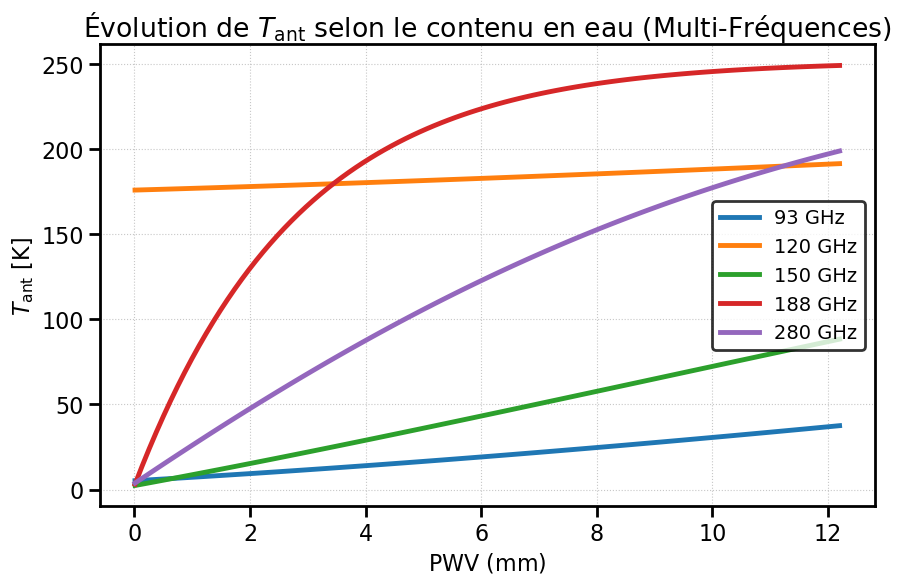

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf.atm
from astropy import units as u

# --- 1. Initialisation des paramètres (Données fournies) ---
pi = np.pi  
f_93 = 93e9   
f_120 = 120e9 
f_145 = 145e9
f_150 = 150e9 
f_179 = 179e9 
f_188 = 188e9 
f_225 = 225e9
f_280 = 280e9

frequencies = np.array([f_93, f_120, f_150, f_188, f_280]) # Array de 4 fréquences

theta_b = np.full(len(frequencies), 1*60*pi/(2*180*3600))
elevation = 45

# Profil atmosphérique de base
altitudes = np.geomspace(1, 15000, 200) + 4999 # m
altitudes_km = (altitudes * u.m).to(u.km)
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value
P_water_base = pycraf.atm.profile_standard(altitudes_km)[3].value # Renommé pour clarté

# --- 2. Boucle de calcul Multi-Fréquences ---

PWV_base = 1.22
x = np.linspace(0.01, 10, 100) # Facteurs d'échelle
PWV_x = x * PWV_base           # Axe X (PWV en mm)

# Initialisation de la matrice de résultats
# Dimensions : [nombre de points PWV, nombre de fréquences]
T_ant_results = np.zeros((len(x), len(frequencies)))

print("Calcul en cours...")

for i, val in enumerate(x):
    
    # Mise à l'échelle de la vapeur d'eau
    P_water_test = P_water_base * val
    
    # Appel de la fonction (qui renvoie un array de taille 4)
    # On stocke le résultat dans la ligne 'i' de la matrice
    T_ant_results[i, :] = Calcul_T_ant_1_el(
        frequencies, 
        theta_b, 
        altitudes, 
        Temperature, 
        Pressure, 
        P_water_test, 
        elevation
    )

# --- 3. Tracé des courbes ---

plt.figure(figsize=(10, 6))

# On boucle sur chaque fréquence pour tracer sa courbe correspondante
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    # On trace PWV vs la colonne j de la matrice de résultats
    plt.plot(PWV_x, T_ant_results[:, j], label=f'{freq_ghz:.0f} GHz')

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.title(r"Évolution de $T_{\mathrm{ant}}$ selon le contenu en eau (Multi-Fréquences)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Fréquence (GHz)      | k (K)      | c (coeff) 
--------------------------------------------------
93                   | 85.94      | 0.0442    
150                  | 5590.12    | 0.0013    
188                  | 252.07     | 0.3625    
280                  | 318.05     | 0.0812    


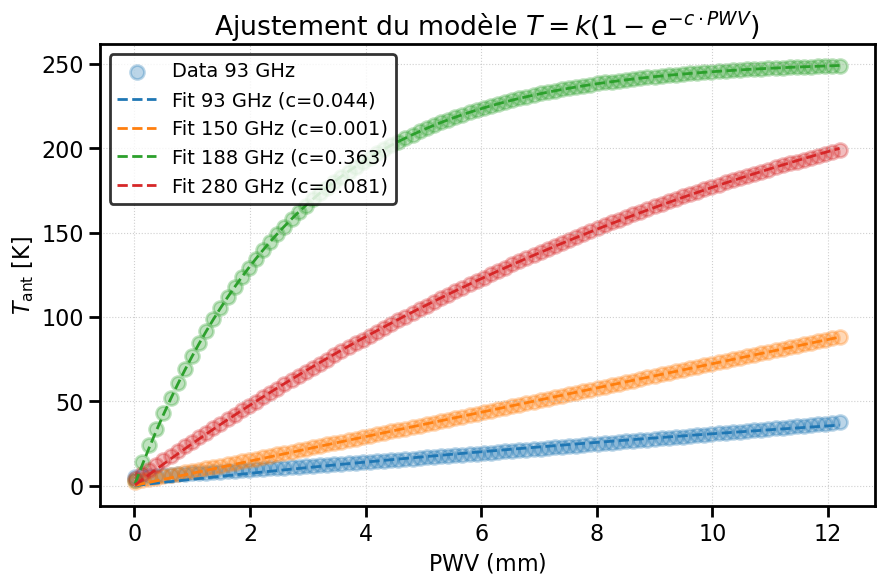

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# 1. Définition du modèle (Saturation exponentielle)
def modele_Tant(pwv, k, c):
    # k : Température asymptotique (proche de T_physique moyenne)
    # c : coefficient lié à l'absorption massique de l'eau
    return k * (1 - np.exp(-c * pwv))

# 2. Boucle sur les fréquences
# On prépare des listes pour stocker les résultats si besoin
k_opt_list = []
c_opt_list = []

print(f"{'Fréquence (GHz)':<20} | {'k (K)':<10} | {'c (coeff)':<10}")
print("-" * 50)

plt.figure(figsize=(10, 6))

for j, freq in enumerate(frequencies):
    if freq == f_120 :
        continue
    freq_ghz = freq / 1e9
    
    # --- A. Sélection des données pour la fréquence j ---
    # x_data est toujours le même (PWV)
    # y_data change : on prend la colonne j
    y_data_freq = T_ant_results[:, j]
    
    # --- B. Le "Fit" (Ajustement) ---
    # p0=[280, 0.1] sont des valeurs initiales pour aider l'algo
    # k ~ 280 K (température ambiante), c ~ 0.1 (absorption)
    try:
        popt, pcov = curve_fit(modele_Tant, PWV_x, y_data_freq, p0=[280, 0.1])
        
        k_val = popt[0]
        c_val = popt[1]
        
        # Stockage
        k_opt_list.append(k_val)
        c_opt_list.append(c_val)
        
        # Affichage console
        print(f"{freq_ghz:<20.0f} | {k_val:<10.2f} | {c_val:<10.4f}")
        
        # --- C. Tracé pour vérification ---
        # On trace les points bruts
        plt.scatter(PWV_x, y_data_freq, alpha=0.3, label=f'Data {freq_ghz:.0f} GHz' if j==0 else "")
        
        # On trace la courbe modèle
        # On crée une ligne lisse pour le modèle
        x_smooth = np.linspace(PWV_x.min(), PWV_x.max(), 200)
        y_model = modele_Tant(x_smooth, k_val, c_val)
        
        #color = plt.gca().lines[-1].get_color() # Récupère la couleur du scatter précédent (astuce matplotlib)
        # Note: scatter ne met pas à jour lines, donc on force la couleur via le cycle ou on laisse auto
        plt.plot(x_smooth, y_model, '--', linewidth=2, label=f'Fit {freq_ghz:.0f} GHz (c={c_val:.3f})')
        
    except RuntimeError:
        print(f"Erreur de fit pour {freq_ghz} GHz")

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.title(r"Ajustement du modèle $T = k(1 - e^{-c \cdot PWV})$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Conversion en arrays numpy pour usage ultérieur
k_opts = np.array(k_opt_list)
c_opts = np.array(c_opt_list)

Calcul en cours...


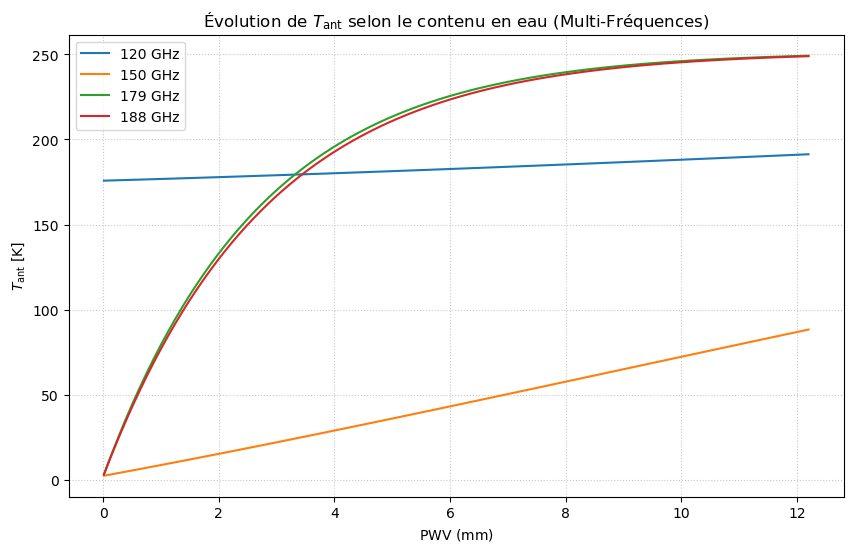

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pycraf.atm
from astropy import units as u

# --- 1. Initialisation des paramètres (Données fournies) ---
pi = np.pi     
f_120 = 120e9 
f_150 = 150e9 
f_179 = 179e9 
f_188 = 188e9 

frequencies = np.array([f_120, f_150, f_179, f_188]) # Array de 4 fréquences

theta_b = np.full(len(frequencies), 1*60*pi/(2*180*3600))
elevation = 45

# Profil atmosphérique de base
altitudes = np.geomspace(1, 15000, 200) + 4999 # m
altitudes_km = (altitudes * u.m).to(u.km)
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value
P_water_base = pycraf.atm.profile_standard(altitudes_km)[3].value # Renommé pour clarté

# --- 2. Boucle de calcul Multi-Fréquences ---

PWV_base = 1.22
x = np.linspace(0.01, 10, 100) # Facteurs d'échelle
PWV_x = x * PWV_base           # Axe X (PWV en mm)

# Initialisation de la matrice de résultats
# Dimensions : [nombre de points PWV, nombre de fréquences]
T_ant_results = np.zeros((len(x), len(frequencies)))

print("Calcul en cours...")

for i, val in enumerate(x):
    
    # Mise à l'échelle de la vapeur d'eau
    P_water_test = P_water_base * val
    
    # Appel de la fonction (qui renvoie un array de taille 4)
    # On stocke le résultat dans la ligne 'i' de la matrice
    T_ant_results[i, :] = Calcul_T_ant_1_el(
        frequencies, 
        theta_b, 
        altitudes, 
        Temperature, 
        Pressure, 
        P_water_test, 
        elevation
    )

# --- 3. Tracé des courbes ---

plt.figure(figsize=(10, 6))

# On boucle sur chaque fréquence pour tracer sa courbe correspondante
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    # On trace PWV vs la colonne j de la matrice de résultats
    plt.plot(PWV_x, T_ant_results[:, j], label=f'{freq_ghz:.0f} GHz')

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.title(r"Évolution de $T_{\mathrm{ant}}$ selon le contenu en eau (Multi-Fréquences)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

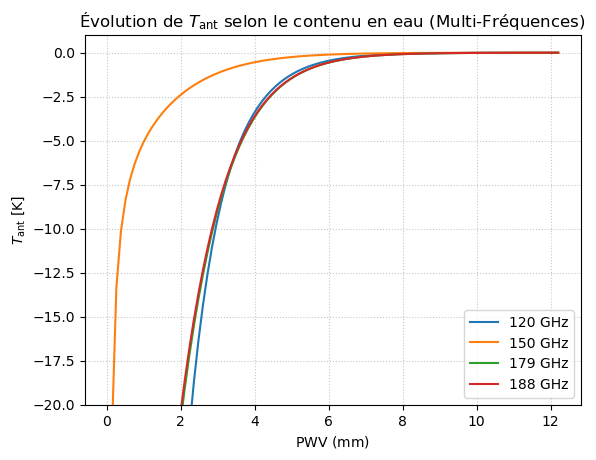

In [12]:
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    # On trace PWV vs la colonne j de la matrice de résultats
    plt.plot(PWV_x, T_ant_results[:, j]/(1-np.exp(PWV_x)), label=f'{freq_ghz:.0f} GHz')

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.ylim(-20,1)
plt.title(r"Évolution de $T_{\mathrm{ant}}$ selon le contenu en eau (Multi-Fréquences)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Fréquence (GHz)      | k (K)      | c (coeff) 
--------------------------------------------------
120                  | 183.12     | 263.8047  
150                  | 5590.12    | 0.0013    
179                  | 251.83     | 0.3766    
188                  | 252.07     | 0.3625    


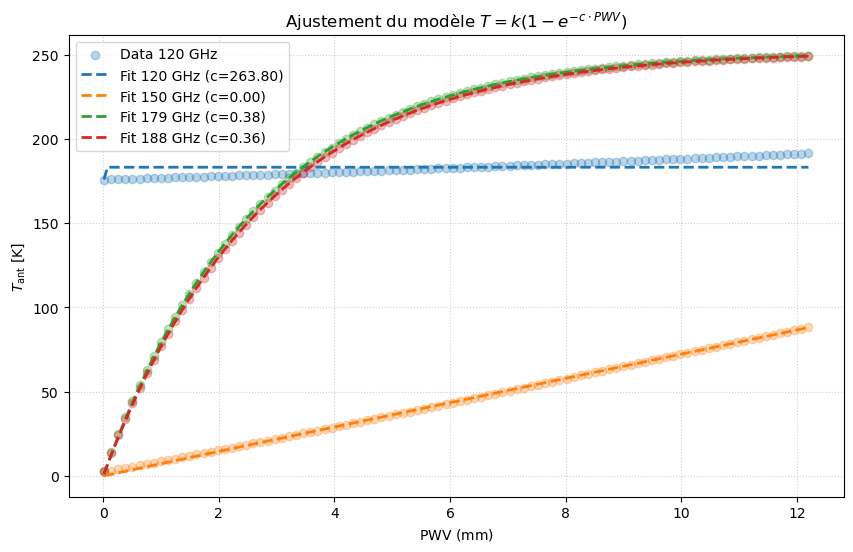

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Définition du modèle (Saturation exponentielle)
def modele_Tant(pwv, k, c):
    # k : Température asymptotique (proche de T_physique moyenne)
    # c : coefficient lié à l'absorption massique de l'eau
    return k * (1 - np.exp(-c * pwv))

# 2. Boucle sur les fréquences
# On prépare des listes pour stocker les résultats si besoin
k_opt_list = []
c_opt_list = []

print(f"{'Fréquence (GHz)':<20} | {'k (K)':<10} | {'c (coeff)':<10}")
print("-" * 50)

plt.figure(figsize=(10, 6))

for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # --- A. Sélection des données pour la fréquence j ---
    # x_data est toujours le même (PWV)
    # y_data change : on prend la colonne j
    y_data_freq = T_ant_results[:, j]
    
    # --- B. Le "Fit" (Ajustement) ---
    # p0=[280, 0.1] sont des valeurs initiales pour aider l'algo
    # k ~ 280 K (température ambiante), c ~ 0.1 (absorption)
    try:
        popt, pcov = curve_fit(modele_Tant, PWV_x, y_data_freq, p0=[280, 0.1])
        
        k_val = popt[0]
        c_val = popt[1]
        
        # Stockage
        k_opt_list.append(k_val)
        c_opt_list.append(c_val)
        
        # Affichage console
        print(f"{freq_ghz:<20.0f} | {k_val:<10.2f} | {c_val:<10.4f}")
        
        # --- C. Tracé pour vérification ---
        # On trace les points bruts
        plt.scatter(PWV_x, y_data_freq, alpha=0.3, label=f'Data {freq_ghz:.0f} GHz' if j==0 else "")
        
        # On trace la courbe modèle
        # On crée une ligne lisse pour le modèle
        x_smooth = np.linspace(PWV_x.min(), PWV_x.max(), 200)
        y_model = modele_Tant(x_smooth, k_val, c_val)
        
        #color = plt.gca().lines[-1].get_color() # Récupère la couleur du scatter précédent (astuce matplotlib)
        # Note: scatter ne met pas à jour lines, donc on force la couleur via le cycle ou on laisse auto
        plt.plot(x_smooth, y_model, '--', linewidth=2, label=f'Fit {freq_ghz:.0f} GHz (c={c_val:.3f})')
        
    except RuntimeError:
        print(f"Erreur de fit pour {freq_ghz} GHz")

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$T_{\mathrm{ant}}$ [K]")
plt.title(r"Ajustement du modèle $T = k(1 - e^{-c \cdot PWV})$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Conversion en arrays numpy pour usage ultérieur
k_opts = np.array(k_opt_list)
c_opts = np.array(c_opt_list)

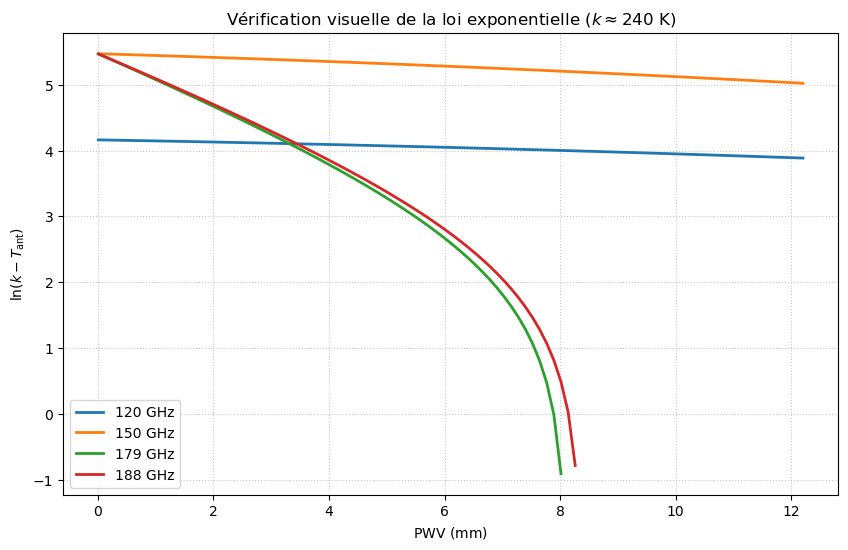

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Choix de la température asymptotique k ---
# Dans l'idéal, c'est la température physique moyenne du milieu.
# On prend ici la température au sol (la première valeur du profil), 
# car T_ant ne peut physiquement pas dépasser cette valeur (corps noir).
k_physique = 240 # C'est un scalaire (environ 288 K pour le profil standard)

plt.figure(figsize=(10, 6))

# --- 2. Boucle sur les fréquences ---
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # Récupération des données T_ant pour cette fréquence
    y_data = T_ant_results[:, j]
    
    # --- Transformation des données ---
    # Formule : Y = ln( k - T_ant )
    # On ajoute une sécurité : on ne garde que les points où T_ant < k
    mask_valid = y_data < k_physique
    
    if np.sum(mask_valid) > 0:
        # On filtre les données
        pwv_valid = PWV_x[mask_valid]
        y_valid = y_data[mask_valid]
        
        # Calcul du logarithme
        # Le terme (k - T) représente le "manque à gagner" pour atteindre la saturation
        log_term = np.log(k_physique - y_valid)
        
        # --- Tracé ---
        plt.plot(pwv_valid, log_term, linewidth=2, label=f'{freq_ghz:.0f} GHz')
        
        # (Optionnel) Calcul de la pente locale pour vérifier c
        # slope = (log_term[-1] - log_term[0]) / (pwv_valid[-1] - pwv_valid[0])
        # print(f"Pente estimée (-c) pour {freq_ghz:.0f} GHz : {slope:.3f}")

# --- 3. Mise en forme ---
plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$\ln(k - T_{\mathrm{ant}})$")
plt.title(r"Vérification visuelle de la loi exponentielle ($k \approx " + f"{k_physique:.0f}$ K)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Si c'est une droite, le modèle est valide.
# La pente de la droite correspond à -c.
plt.show()

Test de l'impact de la hauteur max

Lancement des simulations Monte Carlo pour 4 fréquences...
Processing 120 GHz...
Processing 150 GHz...
Processing 179 GHz...
Processing 188 GHz...


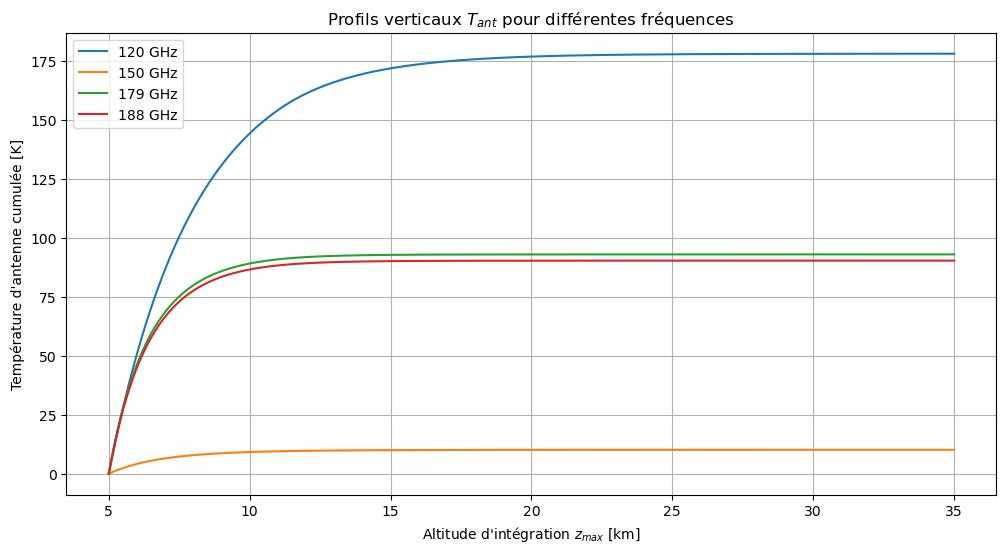

In [18]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
import matplotlib.pyplot as plt

# --- 1. Paramètres initiaux ---
pi = np.pi     

# Définition des multiples fréquences
f_120 = 120e9
f_150 = 150e9
f_179 = 179e9
f_188 = 188e9
frequencies = np.array([f_120, f_150, f_179, f_188]) # Hz

# Theta_b pour chaque fréquence (ici supposé constant à 1 arcmin, 
# mais vous pourriez le faire varier en fct de lambda/D si besoin)
theta_b_all = np.full(len(frequencies), 1*60*pi/(2*180*3600))

elevation = 90
elev = 45 # en deg
N = 500
N_MC = 200

# --- 2. Profils Atmosphériques (Commun à toutes les fréquences) ---
altitudes = np.geomspace(1, 30000, 1000) # m
altitudes = altitudes + 4999 # m

altitudes_km = altitudes * u.m       
altitudes_km = altitudes_km.to(u.km) 

# Récupération des données Pycraf
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value # K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value # hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value # g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value # hPa

# Calcul WVMR
epsilon = 0.622 
WVMR = epsilon * P_water / (Pressure - P_water) # kg/kg
WVMR = WVMR * 1000 # g/kg

# --- 3. Calcul du SNR (Commun car dépend du Lidar, pas du radiomètre) ---
# Valeurs de Patrick
A = 106533.049
c = 1.470303e-05

SNR_no_scale = calcul_snr(A, c, WVMR, altitudes, Pressure, Temperature, elev)
# On prend l'index [0] si scale_snr renvoie un tuple ou array
SNR = scale_snr_for_variable_bins(altitudes, SNR_no_scale, elev=90, dz_ref=30.0)[0]


# --- 4. Boucle de Simulation par Fréquence ---

# Dictionnaire pour stocker les résultats : {frequence: (sigma_prof, T_mean_prof, T_dry_prof)}
results_dict = {}

print(f"Lancement des simulations Monte Carlo pour {len(frequencies)} fréquences...")

for i, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    print(f"Processing {freq_ghz:.0f} GHz...")
    
    # On prépare les arguments scalaires ou tableaux unitaires pour la fonction
    f_input = np.array([freq])
    theta_b_input = np.array([theta_b_all[i]])
    
    # Appel de la fonction MC
    # Renvoie : sigma_prof, T_mean_prof, T_dry_prof
    simu_freq = Monte_Carlo_T_ant_profile(
        f_input, 
        theta_b_input, 
        N, 
        elev, 
        generate_Pwater_MC_lognormal, 
        N_MC, 
        WVMR, 
        SNR, 
        Temperature, 
        Pressure, 
        altitudes
    )
    
    # Stockage
    results_dict[freq] = simu_freq


# --- 5. Exemple de visualisation (Comparaison des fréquences) ---
plt.figure(figsize=(12, 6))

for freq in frequencies:
    freq_ghz = freq / 1e9
    # Récupération des résultats
    sigma_prof, T_mean_prof, T_dry_prof = results_dict[freq]
    
    # On trace T_mean (Total)
    plt.plot(altitudes/1000, T_mean_prof, label=f'{freq_ghz:.0f} GHz')
    
    # Optionnel : afficher sigma en pointillé (x10 pour visibilité)
    # plt.plot(altitudes/1000, sigma_prof*10, '--', alpha=0.5)

plt.xlabel("Altitude d'intégration $z_{max}$ [km]")
plt.ylabel("Température d'antenne cumulée [K]")
plt.title("Profils verticaux $T_{ant}$ pour différentes fréquences")
plt.legend()
plt.grid(True)
plt.show()

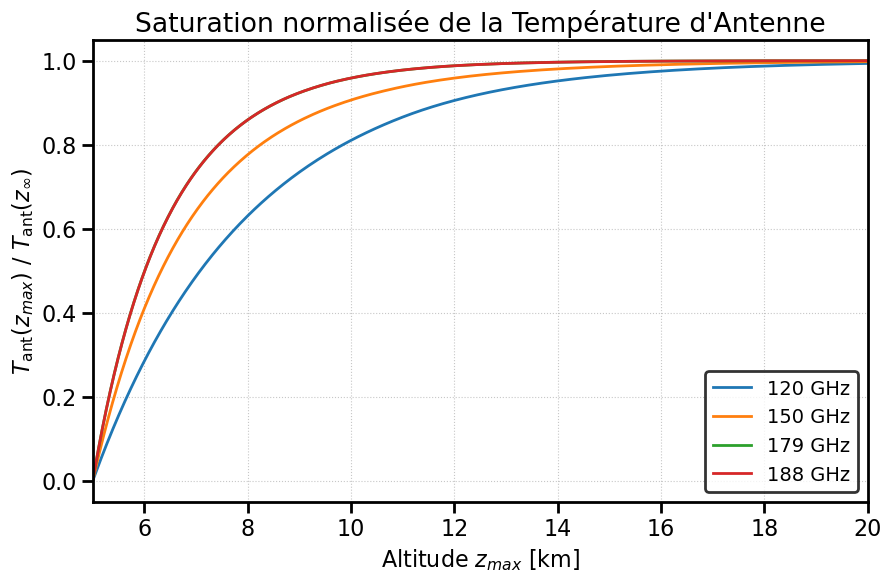

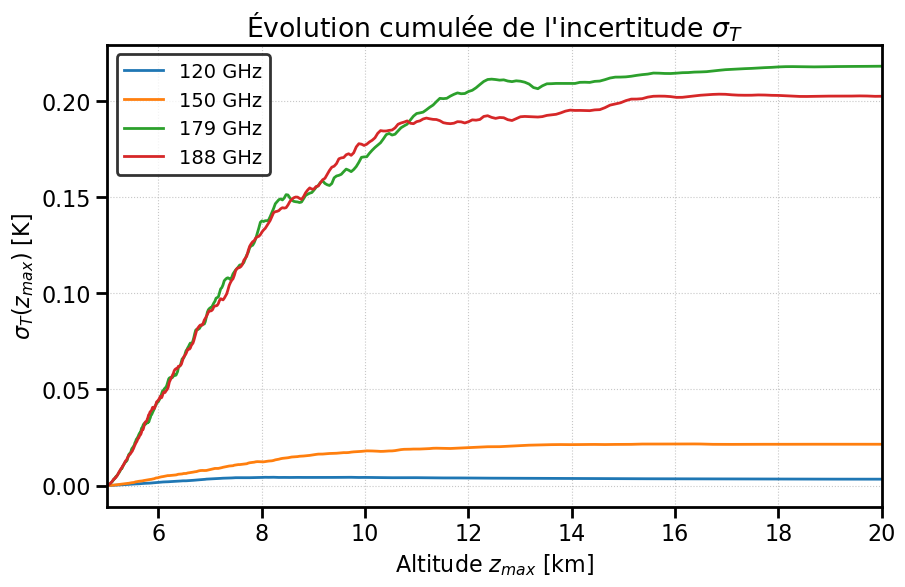

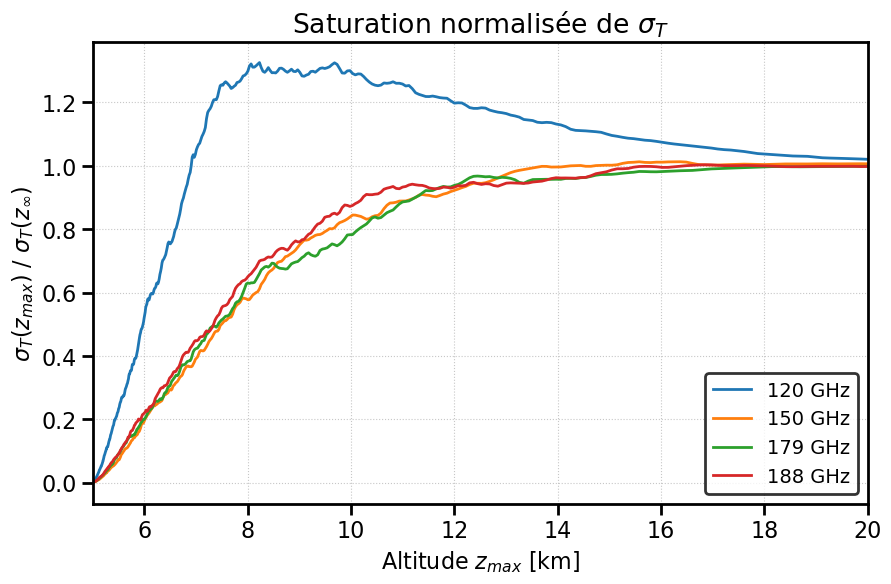

In [60]:
import matplotlib.pyplot as plt
import numpy as np
altitudes = np.geomspace(1, 30000, 1000) # m
altitudes = altitudes + 4999 # m
# Préparation de l'axe X en km
alt_km = altitudes / 1000

# =============================================================================
# Graphique 1 : T_ant Normalisée (T(z) / T_final)
# =============================================================================
plt.figure(figsize=(10, 6))
frequencies = np.array([f_120,f_150, f_179, f_188])
for freq in sorted(frequencies):
    freq_ghz = freq / 1e9
    sigma_prof, T_mean_prof, _ = results_dict[freq]
    
    # Valeur asymptotique (z_infini)
    T_inf = T_mean_prof[-1]
    
    # Normalisation
    # Attention à la division par 0 si T_inf est nul (peu probable physiquement ici)
    T_norm = T_mean_prof / T_inf if T_inf != 0 else np.zeros_like(T_mean_prof)
    
    plt.plot(alt_km, T_norm, label=f'{freq_ghz:.0f} GHz', linewidth=2)

plt.xlabel(r"Altitude $z_{max}$ [km]")
plt.ylabel(r"$T_{\mathrm{ant}}(z_{max}) \ / \ T_{\mathrm{ant}}(z_{\infty})$")
plt.title(r"Saturation normalisée de la Température d'Antenne")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(5, 20) # Zoom sur la partie troposphérique pertinente
plt.show()


# =============================================================================
# Graphique 2 : Sigma_T Absolu en fonction de z
# =============================================================================
plt.figure(figsize=(10, 6))

for freq in sorted(frequencies):
    freq_ghz = freq / 1e9
    sigma_prof, _, _ = results_dict[freq]
    
    # On trace en Kelvin (ou multipliez par 1000 pour des mK)
    plt.plot(alt_km, sigma_prof, label=f'{freq_ghz:.0f} GHz', linewidth=2)

plt.xlabel(r"Altitude $z_{max}$ [km]")
plt.ylabel(r"$\sigma_T(z_{max})$ [K]")
plt.title(r"Évolution cumulée de l'incertitude $\sigma_T$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(5, 20)
plt.show()


# =============================================================================
# Graphique 3 : Sigma_T Normalisé (Sigma(z) / Sigma_final)
# =============================================================================
plt.figure(figsize=(10, 6))

for freq in sorted(frequencies):
    freq_ghz = freq / 1e9
    sigma_prof, _, _ = results_dict[freq]
    
    # Valeur asymptotique
    sigma_inf = sigma_prof[-1]
    
    # Normalisation
    if sigma_inf > 0:
        sigma_norm = sigma_prof / sigma_inf
    else:
        sigma_norm = np.zeros_like(sigma_prof)
    
    plt.plot(alt_km, sigma_norm, label=f'{freq_ghz:.0f} GHz', linewidth=2)

plt.xlabel(r"Altitude $z_{max}$ [km]")
plt.ylabel(r"$\sigma_T(z_{max}) \ / \ \sigma_T(z_{\infty})$")
plt.title(r"Saturation normalisée de $\sigma_T$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(5, 20)
plt.show()

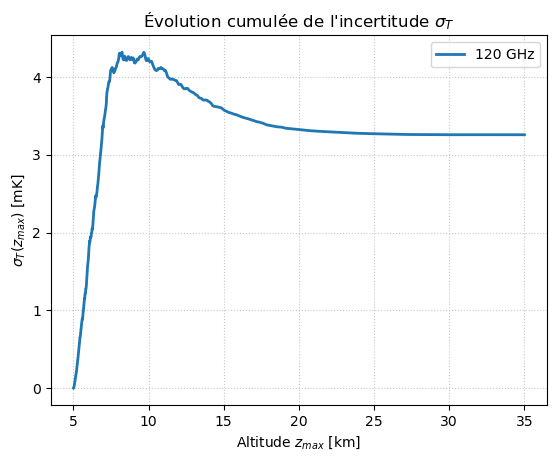

In [22]:
sigma_prof, T_mean_prof, _ = results_dict[f_120]

plt.plot(alt_km, sigma_prof*1000, label=f'{f_120/1e9:.0f} GHz', linewidth=2)

plt.xlabel(r"Altitude $z_{max}$ [km]")
plt.ylabel(r"$\sigma_T(z_{max})$ [mK]")
plt.title(r"Évolution cumulée de l'incertitude $\sigma_T$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

On observe plus haut un effetv de saturation de l'atmosphère

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_79561/4120702984.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(alt_km, sigma_prof/T_mean_prof*100, label=f'{f_120/1e9:.0f} GHz', linewidth=2)


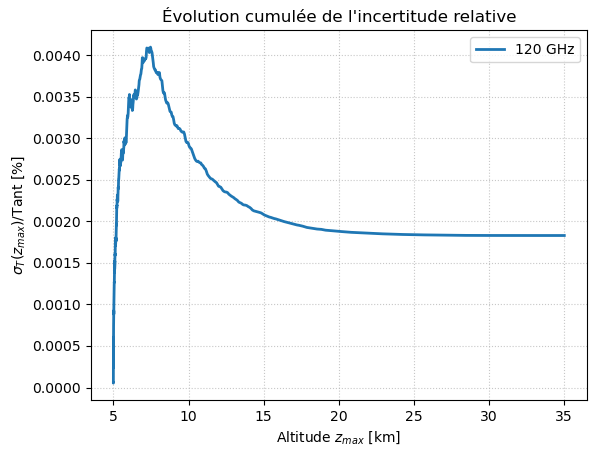

In [25]:
sigma_prof, T_mean_prof, _ = results_dict[f_120]

plt.plot(alt_km, sigma_prof/T_mean_prof*100, label=f'{f_120/1e9:.0f} GHz', linewidth=2)

plt.xlabel(r"Altitude $z_{max}$ [km]")
plt.ylabel(r"$\sigma_T(z_{max})$/Tant [%]")
plt.title(r"Évolution cumulée de l'incertitude relative")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

/var/folders/z2/6hps10m55pd3mdx0n4vzfvy9w8t2v4/T/ipykernel_79561/1220050626.py:14: RuntimeWarning: invalid value encountered in divide
  plt.plot(alt_km, sigma_prof/T_mean_prof*100, label=f'{freq_ghz:.0f} GHz', linewidth=2)


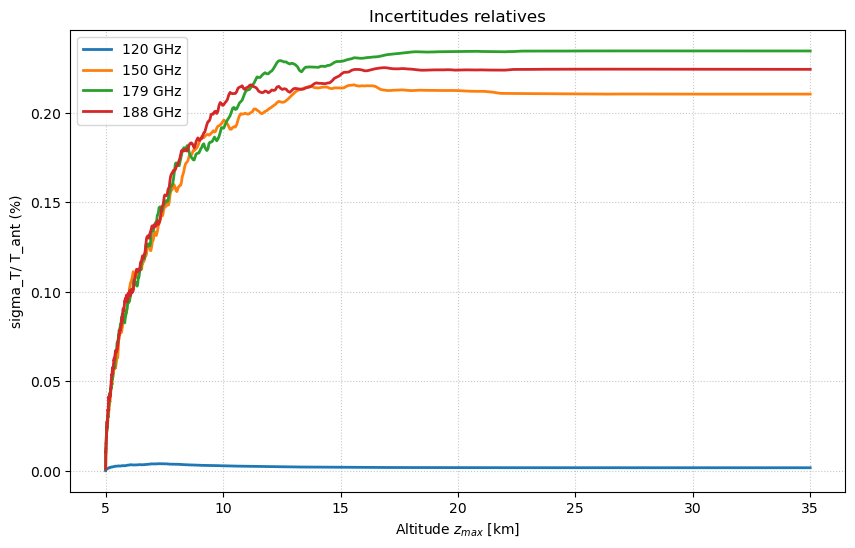

In [24]:
plt.figure(figsize=(10, 6))

for freq in sorted(frequencies):
    freq_ghz = freq / 1e9
    sigma_prof, T_mean_prof, _ = results_dict[freq]
    
    # Valeur asymptotique (z_infini)
    T_inf = T_mean_prof[-1]
    
    # Normalisation
    # Attention à la division par 0 si T_inf est nul (peu probable physiquement ici)
    T_norm = T_mean_prof / T_inf if T_inf != 0 else np.zeros_like(T_mean_prof)
    
    plt.plot(alt_km, sigma_prof/T_mean_prof*100, label=f'{freq_ghz:.0f} GHz', linewidth=2)

plt.xlabel(r"Altitude $z_{max}$ [km]")
plt.ylabel("sigma_T/ T_ant (%)")
plt.title("Incertitudes relatives")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
#plt.xlim(0, 20) # Zoom sur la partie troposphérique pertinente
plt.show()

Test de l'impact de PWV sur sigma_T

In [36]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid  # Pour l'intégration numérique
import matplotlib.pyplot as plt


# =============================================================================
# 2. INITIALISATION ET MAILLAGE HAUTE RÉSOLUTION (z_1)
# =============================================================================

# Paramètres généraux
pi = np.pi     

elev = 45
N_MC = 200
epsilon = 0.622
R_water = 461.5 # J/kg/K

# -- 2a. Création de la grille fine linéaire (z_1) --
# On prend large (ex: 2000 points) pour avoir une bonne précision sur z_moy et z_break
altitudes_hr = np.linspace(5000, 15000, 2000) # m
z_1 = altitudes_hr
z_1_km = (z_1 * u.m).to(u.km)

# -- 2b. Récupération des profils Pycraf sur la grille fine --
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value        # K
P_1 = profile[1].value        # hPa
rho_water_1_base = profile[2].value # g/m^3 (Profil standard de base)
P_water_1_base = profile[3].value   # hPa (Profil standard de base)

# =============================================================================
# 3. CRÉATION DE LA GRILLE RÉDUITE OPTIMISÉE (zg)
# =============================================================================

N_Z = 200
N_lin = 4 * N_Z // 5
N_geom = N_Z - N_lin
gamma = 2
Z_FLOOR = 5000

# Calcul du z_break sur le profil standard (la forme ne change pas avec le scaling)
z_break = calcul_z_percentile_wvc(z_1, rho_water_1_base, 90)
print(f"Altitude de coupure (90% eau) : {z_break:.1f} m")

zmin = max(float(np.nanmin(z_1)), Z_FLOOR)
zmax = float(np.nanmax(z_1))

# Génération du maillage réduit
zg = hybrid_lin_geom(zmin, z_break, zmax, N_lin=N_lin, N_geom=N_geom, gamma=gamma)
# ... (votre code précédent pour les imports et profils) ...

# =============================================================================
# 4. BOUCLE DE CALCUL AVEC SCALING PWV
# =============================================================================

# Facteurs d'échelle PWV
x_scale = np.linspace(0.01, 10, 20)

# --- CORRECTION 1 : Initialisation en 2D ---
# On récupère le nombre de fréquences
num_freqs = len(frequencies) 
num_iters = len(x_scale)

# Dimensions : (Nombre d'itérations, Nombre de fréquences)
sigma_T_results = np.zeros((num_iters, num_freqs))
T_ant_results = np.zeros((num_iters, num_freqs))

# Les autres vecteurs scalaires restent en 1D
z_moy_results = np.zeros(num_iters)
std_vert_results = np.zeros(num_iters)
PWV_results = np.zeros(num_iters)

print(f"Lancement de la simulation pour {len(x_scale)} points et {num_freqs} fréquences...")

for i, val in enumerate(x_scale):
    
    # --- A. Mise à l'échelle sur la grille HAUTE RÉSOLUTION (z_1) ---
    P_water_1_scaled = P_water_1_base * val
    
    # Recalcul de rho_water sur z_1
    rho_water_1_scaled = (P_water_1_scaled * 100) / (R_water * T_1) * 1000 # g/m^3
    
    # --- B. Calcul des statistiques verticales sur z_1 ---
    current_PWV = trapezoid(rho_water_1_scaled, z_1)
    
    # Sécurité division par zéro si PWV très faible
    if current_PWV < 1e-9:
        current_PWV = 1e-9
        
    z_moy = trapezoid(rho_water_1_scaled * z_1, z_1) / current_PWV
    var_vert = trapezoid(rho_water_1_scaled * (z_1 - z_moy)**2, z_1) / current_PWV
    std_vert = np.sqrt(var_vert)
    
    # Stockage des stats scalaires
    z_moy_results[i] = z_moy
    std_vert_results[i] = std_vert
    PWV_results[i] = current_PWV / 1000 
    
    # --- C. Interpolation vers la grille RÉDUITE (zg) pour Monte Carlo ---
    T_g = np.interp(zg, z_1, T_1)
    P_g = np.interp(zg, z_1, P_1)
    P_water_g = np.interp(zg, z_1, P_water_1_scaled)
    
    denom = P_g - P_water_g
    denom[denom <= 0] = 1e-6 
    WVMR_g = epsilon * P_water_g / denom * 1000 # g/kg
    
    # --- D. Appel de la fonction de prédiction ---
    sig, temp = predict_SNR_T(
        frequency=frequencies,
        theta_b=theta_b,
        z=zg,           
        WVMR=WVMR_g,    
        elev=elev,
        T=T_g,
        P=P_g,
        N_MC=N_MC
    )
    
    # --- CORRECTION 2 : Assignation dans la matrice ---
    # On remplit toute la ligne i avec les valeurs des différentes fréquences
    sigma_T_results[i, :] = sig
    T_ant_results[i, :] = temp

print("Calcul terminé.")

Altitude de coupure (90% eau) : 9487.4 m
Lancement de la simulation pour 20 points et 4 fréquences...


Calcul terminé.


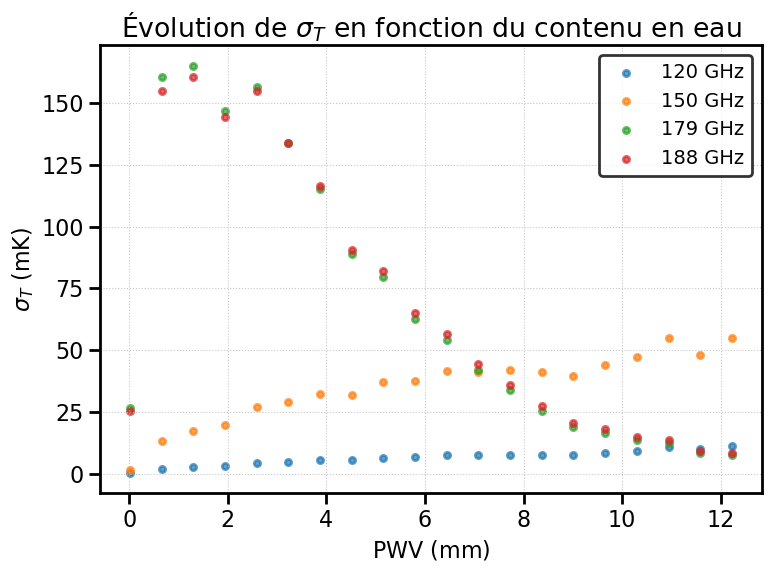

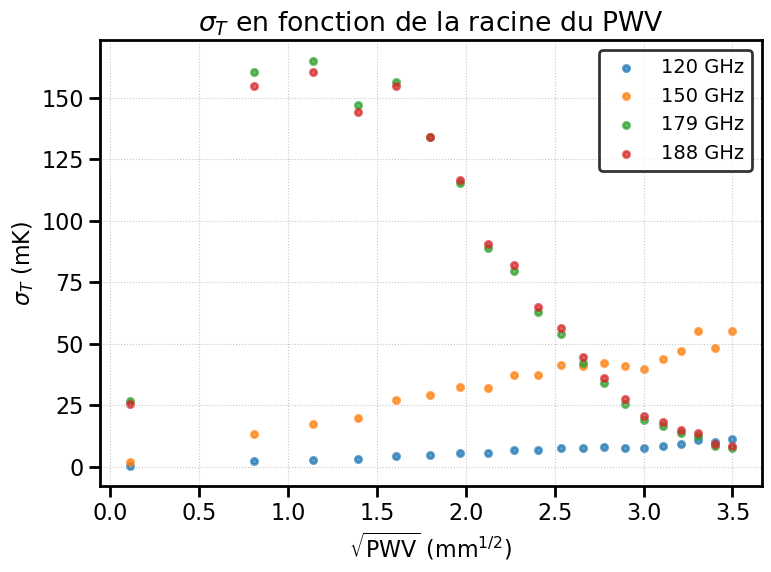

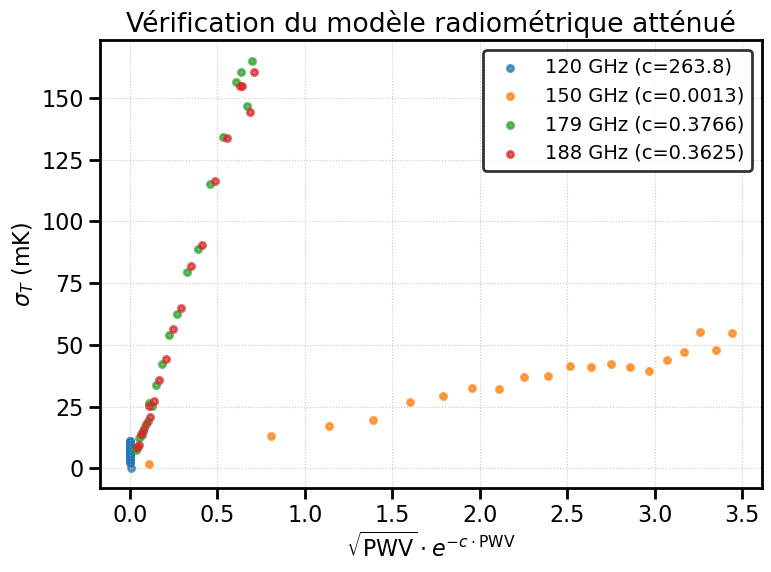

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Définition des coefficients c ---
# Dictionnaire { Fréquence_Hz : coefficient_c }
c_coeffs = {
    120e9: 263.8,   # Valeur fournie
    150e9: 0.0013,
    179e9: 0.3766,
    188e9: 0.3625
}

# --- 2. Figure 1 : Sigma_T en fonction de PWV ---
plt.figure(figsize=(8, 6))

for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # Données
    x_val = PWV_results
    y_val = sigma_T_results[:, j] * 1000 # Conversion en mK
    
    plt.scatter(x_val, y_val, s=20, alpha=0.7, label=f'{freq_ghz:.0f} GHz')

plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$\sigma_{T} \ (\mathrm{mK})$")
plt.title(r"Évolution de $\sigma_T$ en fonction du contenu en eau")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


# --- 3. Figure 2 : Sigma_T en fonction de sqrt(PWV) ---
plt.figure(figsize=(8, 6))

for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # Données
    x_val = np.sqrt(PWV_results)
    y_val = sigma_T_results[:, j] * 1000
    
    plt.scatter(x_val, y_val, s=20, alpha=0.7, label=f'{freq_ghz:.0f} GHz')

plt.xlabel(r"$\sqrt{\mathrm{PWV}} \ (\mathrm{mm}^{1/2})$")
plt.ylabel(r"$\sigma_{T} \ (\mathrm{mK})$")
plt.title(r"$\sigma_T$ en fonction de la racine du PWV")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


# --- 4. Figure 3 : Sigma_T en fonction du modèle physique complet ---
plt.figure(figsize=(8, 6))

for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    if freq in c_coeffs:
        c = c_coeffs[freq]
        
        # Données X transformées par le modèle
        # X = sqrt(PWV) * exp(-c * PWV)
        x_val = np.sqrt(PWV_results) * np.exp(-c * PWV_results)
        y_val = sigma_T_results[:, j] * 1000
        
        plt.scatter(x_val, y_val, s=20, alpha=0.7, label=f'{freq_ghz:.0f} GHz (c={c})')

plt.xlabel(r"$\sqrt{\mathrm{PWV}} \cdot e^{-c \cdot \mathrm{PWV}}$")
plt.ylabel(r"$\sigma_{T} \ (\mathrm{mK})$")
plt.title(r"Vérification du modèle radiométrique atténué")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Estimation du c par régression linéaire

Fréquence  | Pente (A)    | c identifié  | K (constante)
-------------------------------------------------------
120 GHz    | 0.0299       | -0.0149       | 6.30e-06
150 GHz    | -0.0133       | 0.0067       | 2.55e-04
179 GHz    | -0.7906       | 0.3953       | 6.49e-02
188 GHz    | -0.7638       | 0.3819       | 5.95e-02


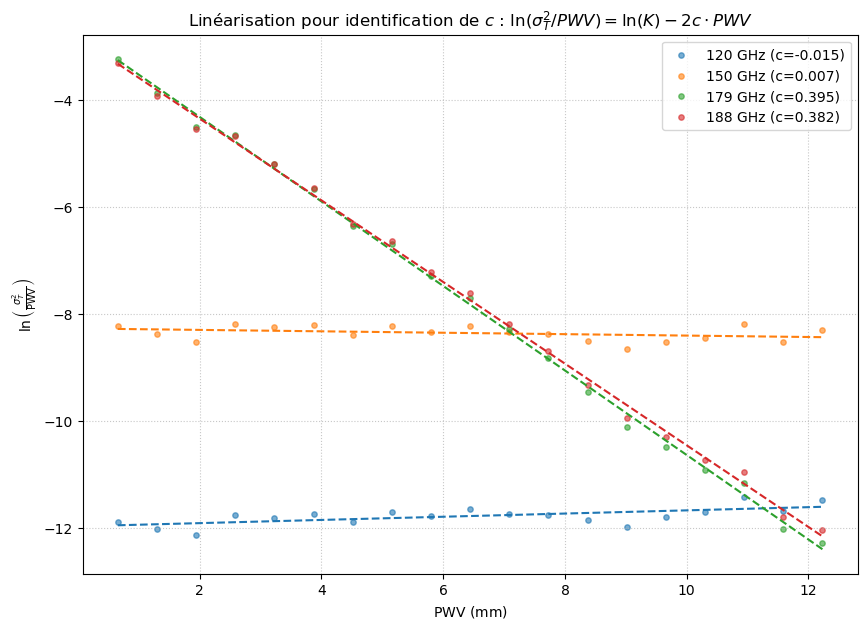

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# --- Paramètres de tracé ---
plt.figure(figsize=(10, 7))

print(f"{'Fréquence':<10} | {'Pente (A)':<12} | {'c identifié':<12} | {'K (constante)':<12}")
print("-" * 55)

# Boucle sur les fréquences
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # 1. Préparation des données (Filtrage pour éviter log(0) ou division par 0)
    # On prend uniquement les PWV > 0.05 mm pour la stabilité numérique
    mask = PWV_results > 0.05
    
    X_data = PWV_results[mask]
    sigma_data = sigma_T_results[mask, j] # On garde les unités telles quelles
    
    # 2. Transformation Y = ln( sigma^2 / PWV )
    # Terme dans le log
    term_inside = (sigma_data**2) / X_data
    Y_data = np.log(term_inside)
    
    # 3. Régression Linéaire (Polyfit de degré 1)
    # Returns: [pente, ordonnée_origine]
    slope, intercept = np.polyfit(X_data, Y_data, 1)
    
    # 4. Identification des paramètres physiques
    c_found = -slope / 2
    K_found = np.exp(intercept)
    
    # Affichage console
    print(f"{freq_ghz:.0f} GHz    | {slope:.4f}       | {c_found:.4f}       | {K_found:.2e}")
    
    # 5. Tracé
    # Points expérimentaux transformés
    plt.scatter(X_data, Y_data, s=15, alpha=0.6, label=f'{freq_ghz:.0f} GHz (c={c_found:.3f})')
    
    # Droite de régression
    plt.plot(X_data, slope * X_data + intercept, linestyle='--', linewidth=1.5)

# --- Mise en forme ---
plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$\ln\left( \frac{\sigma_T^2}{\mathrm{PWV}} \right)$")
plt.title(r"Linéarisation pour identification de $c$ : $\ln(\sigma_T^2/PWV) = \ln(K) - 2c \cdot PWV$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Sauvegarde
# plt.savefig(out_dir / "identification_parametre_c.pdf", bbox_inches='tight')

plt.show()

Fréquence  | c Simulé   | c Théorique | Écart Relatif  
-------------------------------------------------------
/!\ Pente théorique pour 120 GHz trop forte (-527.6) pour être affichée.
120 GHz    | -0.0149     | 263.8000     | 100.0 %
150 GHz    | 0.0067     | 0.0013     | 411.8 %
179 GHz    | 0.3953     | 0.3766     | 5.0 %
188 GHz    | 0.3819     | 0.3625     | 5.4 %


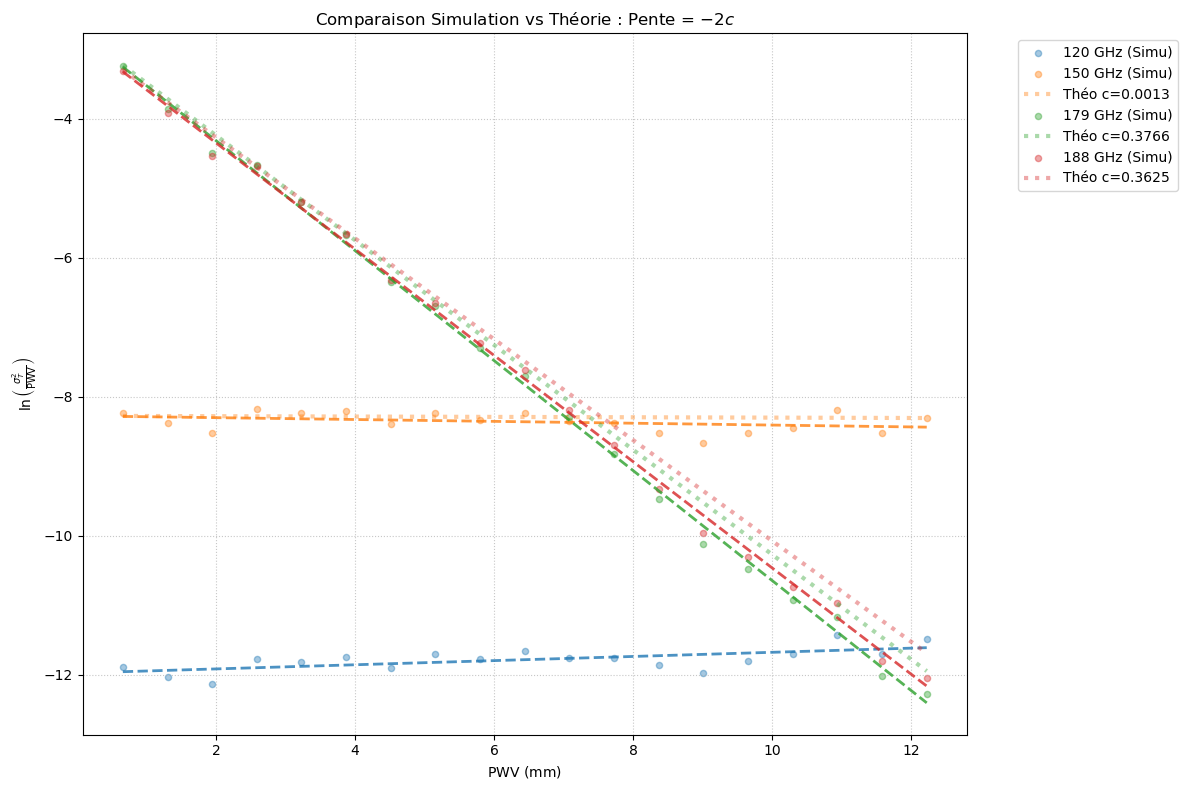

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Rappel des coefficients théoriques fournis ---
c_coeffs_theo = {
    120e9: 263.8,    # /!\ Valeur très élevée, risque d'écraser le graphe si c'est bien un coef d'atténuation
    150e9: 0.0013,
    179e9: 0.3766,
    188e9: 0.3625
}

plt.figure(figsize=(12, 8))

print(f"{'Fréquence':<10} | {'c Simulé':<10} | {'c Théorique':<10} | {'Écart Relatif':<15}")
print("-" * 55)

for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # --- Préparation des données ---
    # On filtre les PWV très faibles pour éviter les instabilités du log
    mask = PWV_results > 0.1 
    X_data = PWV_results[mask]
    sigma_data = sigma_T_results[mask, j]
    
    # Transformation Y = ln( sigma^2 / PWV )
    term_inside = (sigma_data**2) / X_data
    Y_data = np.log(term_inside)
    
    # --- A. Régression sur la Simulation (Fit) ---
    slope_simu, intercept_simu = np.polyfit(X_data, Y_data, 1)
    c_simu = -slope_simu / 2
    
    # --- Tracé des points et du Fit ---
    # On récupère la couleur pour que les lignes soient assorties aux points
    scatter = plt.scatter(X_data, Y_data, s=20, alpha=0.4, label=f'{freq_ghz:.0f} GHz (Simu)')
    color = scatter.get_facecolor()[0] # Récupère la couleur du nuage de points
    
    # Ligne de régression (Simulée)
    plt.plot(X_data, slope_simu * X_data + intercept_simu, 
             linestyle='--', linewidth=2, color=color, alpha=0.8)
    
    # --- B. Tracé de la Prédiction Théorique ---
    if freq in c_coeffs_theo:
        c_theo = c_coeffs_theo[freq]
        
        # Pente théorique attendue : -2 * c
        slope_theo = -2 * c_theo
        
        # On utilise l'intercept de la simulation pour aligner les courbes verticalement
        # et ne comparer que les pentes (l'atténuation)
        Y_theo = slope_theo * X_data + intercept_simu
        
        # Ligne théorique (Pointillés)
        # Note : Pour 120 GHz, si c=263, la pente sera verticale (-526), on la limite pour l'affichage
        if abs(slope_theo) < 50: 
            plt.plot(X_data, Y_theo, linestyle=':', linewidth=3, color=color, 
                     label=f'Théo c={c_theo}')
        else:
            print(f"/!\\ Pente théorique pour {freq_ghz:.0f} GHz trop forte (-{2*c_theo:.1f}) pour être affichée.")

        # Calcul de l'écart
        diff_rel = abs(c_simu - c_theo) / c_theo * 100 if c_theo != 0 else 0
        print(f"{freq_ghz:.0f} GHz    | {c_simu:.4f}     | {c_theo:.4f}     | {diff_rel:.1f} %")
    
    else:
        print(f"{freq_ghz:.0f} GHz    | {c_simu:.4f}     | N/A            | -")

# --- Mise en forme ---
plt.xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
plt.ylabel(r"$\ln\left( \frac{\sigma_T^2}{\mathrm{PWV}} \right)$")
plt.title(r"Comparaison Simulation vs Théorie : Pente = $-2c$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Légende à l'extérieur pour lisibilité
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
import numpy as np
import pycraf
from pycraf import conversions as cnv
from astropy import units as u
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

# =============================================================================
# 1. FONCTIONS ET INITIALISATION
# =============================================================================

def hybrid_lin_geom(zmin, zbreak, zmax, N_lin=80, N_geom=70, gamma=1.0):
    # Fonction de maillage (Rappel si elle n'est pas déjà chargée)
    z1 = np.linspace(zmin, zbreak, N_lin, endpoint=False)
    t = np.linspace(0, 1, N_geom)
    z2 = zbreak * (zmax / zbreak)**(t**gamma)
    return np.concatenate([z1, z2])

def add_gaussian_layer(z, profile_base, center_alt, width, amplitude):
    """
    Ajoute une couche gaussienne au profil de base.
    """
    gaussian = amplitude * np.exp(-0.5 * ((z - center_alt) / width)**2)
    return profile_base + gaussian

# --- Paramètres fixes et Fréquences ---
pi = np.pi     

# --- MODIFICATION 1 : Tableau de fréquences ---
frequencies = np.array([120e9, 150e9, 179e9, 188e9]) # Hz
# Theta_b adapté à la taille du tableau de fréquences
theta_b = np.full(len(frequencies), 1*60*pi/(2*180*3600))

elev = 90
N_MC = 200
epsilon = 0.622
R_water = 461.5
N_Z = 150
Z_obs = 5000 

# --- Grille Haute Résolution (z_1) pour la physique ---
z_1 = np.linspace(5000, 15000, 2000) # m
z_1_km = (z_1 * u.m).to(u.km)

# Profils de base Pycraf
profile = pycraf.atm.profile_standard(z_1_km)
T_1 = profile[0].value        # K
P_1 = profile[1].value        # hPa
P_water_base = profile[3].value # Profil de forme de base

# Calcul de la saturation (Physique)
Tc = T_1 - 273.15
P_sat = 6.112 * np.exp((17.67 * Tc) / (Tc + 243.5))

# --- Grille Réduite (zg) pour le calcul Monte Carlo ---
z_break_fixe = 9000 
N_lin = 4 * N_Z // 5
N_geom = N_Z - N_lin
zg = hybrid_lin_geom(5000, z_break_fixe, 20000, N_lin=N_lin, N_geom=N_geom, gamma=2)

# Interpolation du T et P sur la grille réduite
T_g = np.interp(zg, z_1, T_1)
P_g = np.interp(zg, z_1, P_1)


# =============================================================================
# 2. BOUCLE DE GÉNÉRATION ALÉATOIRE (MULTI-FRÉQUENCES)
# =============================================================================

N_scenarios = 100 
num_freqs = len(frequencies)

# --- MODIFICATION 2 : Tableaux de résultats en 2D ---
# Dimensions : (Nombre de scénarios, Nombre de fréquences)
sigma_T_res = np.zeros((N_scenarios, num_freqs))
T_ant_res = np.zeros((N_scenarios, num_freqs))

# Ces tableaux restent en 1D car ils dépendent uniquement de l'atmosphère, pas de la fréquence
PWV_res = np.zeros(N_scenarios)
z_moy_res = np.zeros(N_scenarios)
std_vert_res = np.zeros(N_scenarios)

print(f"Génération de {N_scenarios} atmosphères pour {num_freqs} fréquences...")

for i in range(N_scenarios):
    
    # --- A. Tirage des paramètres de la couche (Perturbation) ---
    z_layer = np.random.uniform(5500, 7000)
    width_layer = np.random.uniform(200, 1000)
    amp_layer = np.random.uniform(0.0, 2.5) 
    bg_scale = np.random.uniform(0.2, 1.0)
    
    # --- B. Création du profil P_water modifié sur z_1 ---
    P_base_scaled = P_water_base * bg_scale
    P_water_final = add_gaussian_layer(z_1, P_base_scaled, z_layer, width_layer, amp_layer)
    
    # Clipping Saturation
    P_water_final = np.minimum(P_water_final, P_sat)
    
    # Calcul de rho_water (loi gaz parfaits)
    rho_water_scaled = (P_water_final * 100) / (R_water * T_1) * 1000 # g/m3
    
    # --- C. Calcul des statistiques Atmosphériques (Indépendant de la fréquence) ---
    current_PWV = trapezoid(rho_water_scaled, z_1)
    if current_PWV < 1e-6: current_PWV = 1e-6
        
    z_moy = trapezoid(rho_water_scaled * z_1, z_1) / current_PWV
    var_vert = trapezoid(rho_water_scaled * (z_1 - z_moy)**2, z_1) / current_PWV
    std_vert = np.sqrt(var_vert)
    
    # Stockage (Atmosphère)
    PWV_res[i] = current_PWV 
    z_moy_res[i] = z_moy
    std_vert_res[i] = std_vert
    
    # --- D. Interpolation et Appel Radiométrique ---
    
    P_water_g = np.interp(zg, z_1, P_water_final)
    
    denom = P_g - P_water_g
    denom[denom <= 0] = 1e-6
    WVMR_g = epsilon * P_water_g / denom * 1000 # g/kg
    
    # Appel de la fonction avec le tableau complet de fréquences
    # On suppose que predict_SNR_T renvoie des arrays de taille (num_freqs,)
    sig, temp = predict_SNR_T(
        frequency=frequencies,  # <-- Tableau
        theta_b=theta_b,        # <-- Tableau
        z=zg,
        WVMR=WVMR_g,
        elev=elev,
        T=T_g,
        P=P_g,
        N_MC=N_MC
    )
    
    # --- MODIFICATION 3 : Stockage 2D ---
    # On remplit la ligne i avec les valeurs de toutes les fréquences
    sigma_T_res[i, :] = sig
    T_ant_res[i, :] = temp

print("Simulation terminée.")



Génération de 100 atmosphères pour 4 fréquences...
Simulation terminée.


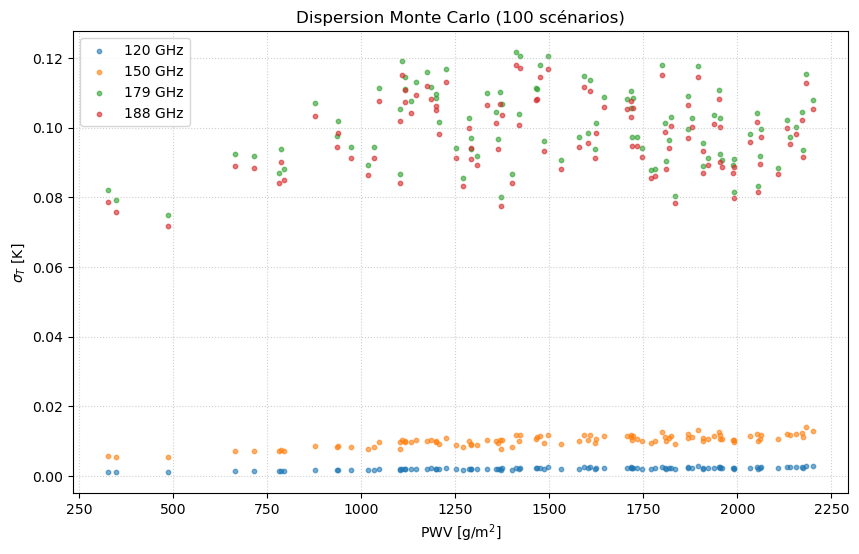

In [41]:
# =============================================================================
# 3. EXEMPLE DE VISUALISATION RAPIDE
# =============================================================================

plt.figure(figsize=(10, 6))
# On trace Sigma_T vs PWV pour chaque fréquence
for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    plt.scatter(PWV_res, sigma_T_res[:, j], s=10, label=f'{freq_ghz:.0f} GHz', alpha=0.6)

plt.xlabel("PWV [g/m$^2$]")
plt.ylabel(r"$\sigma_T$ [K]")
plt.title(f"Dispersion Monte Carlo ({N_scenarios} scénarios)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [43]:
PWV_res = PWV_res/1000 #from g/m2 to kg/m2 ie mm

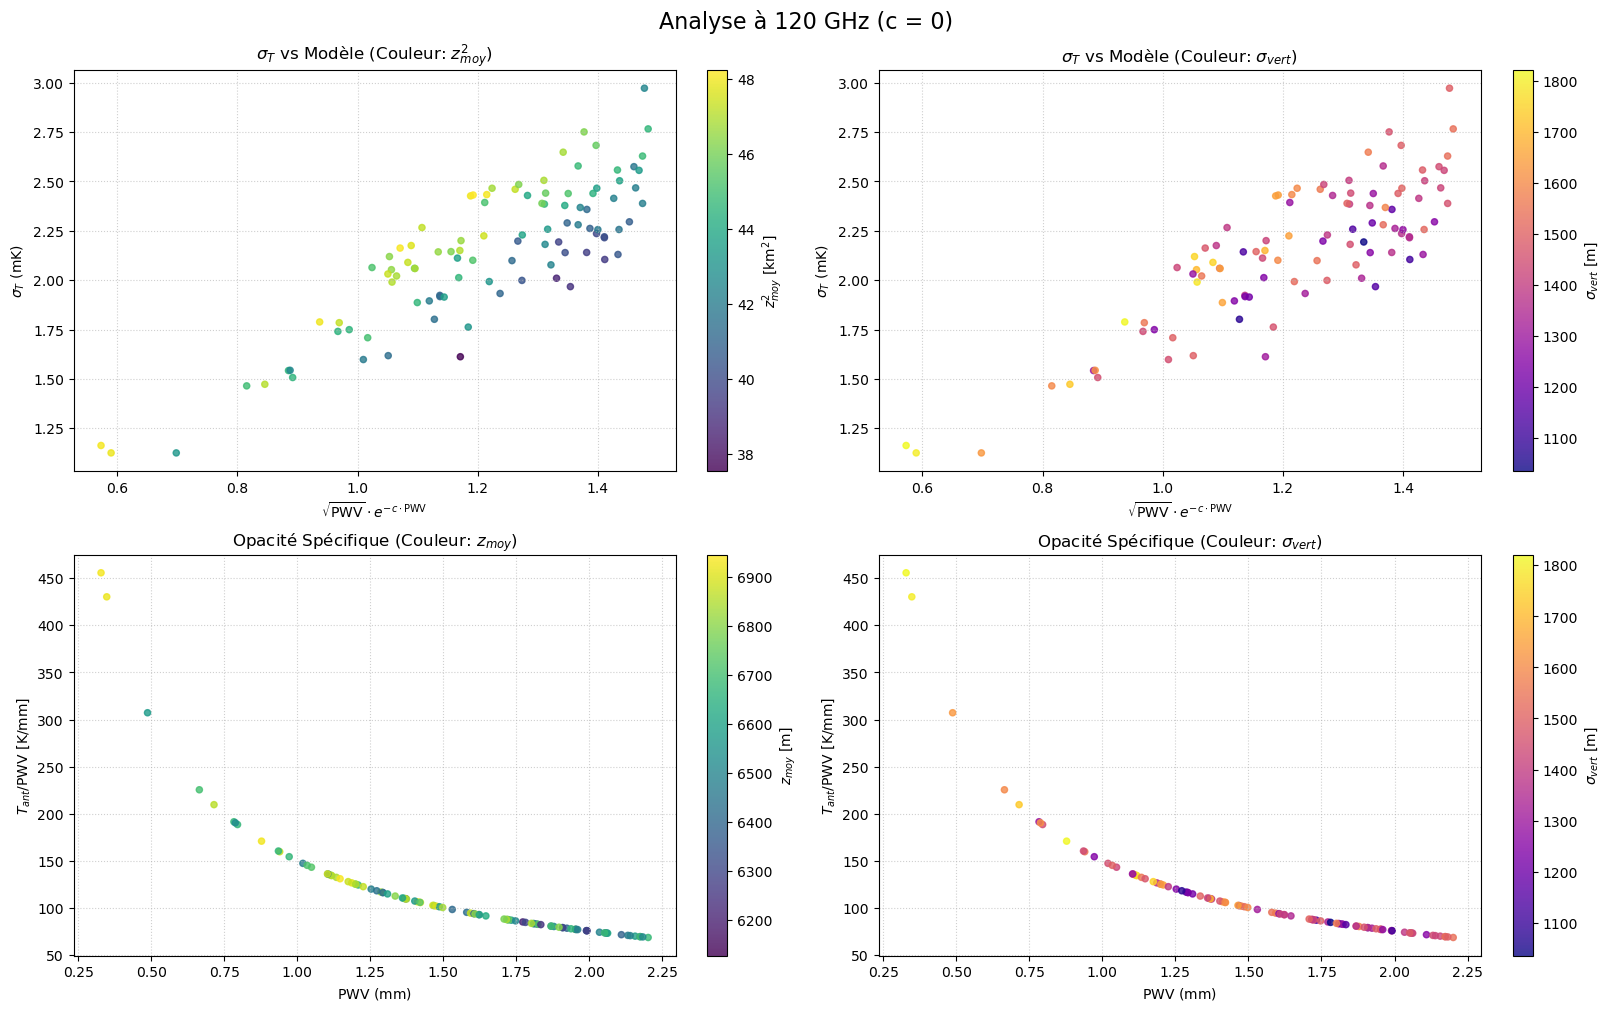

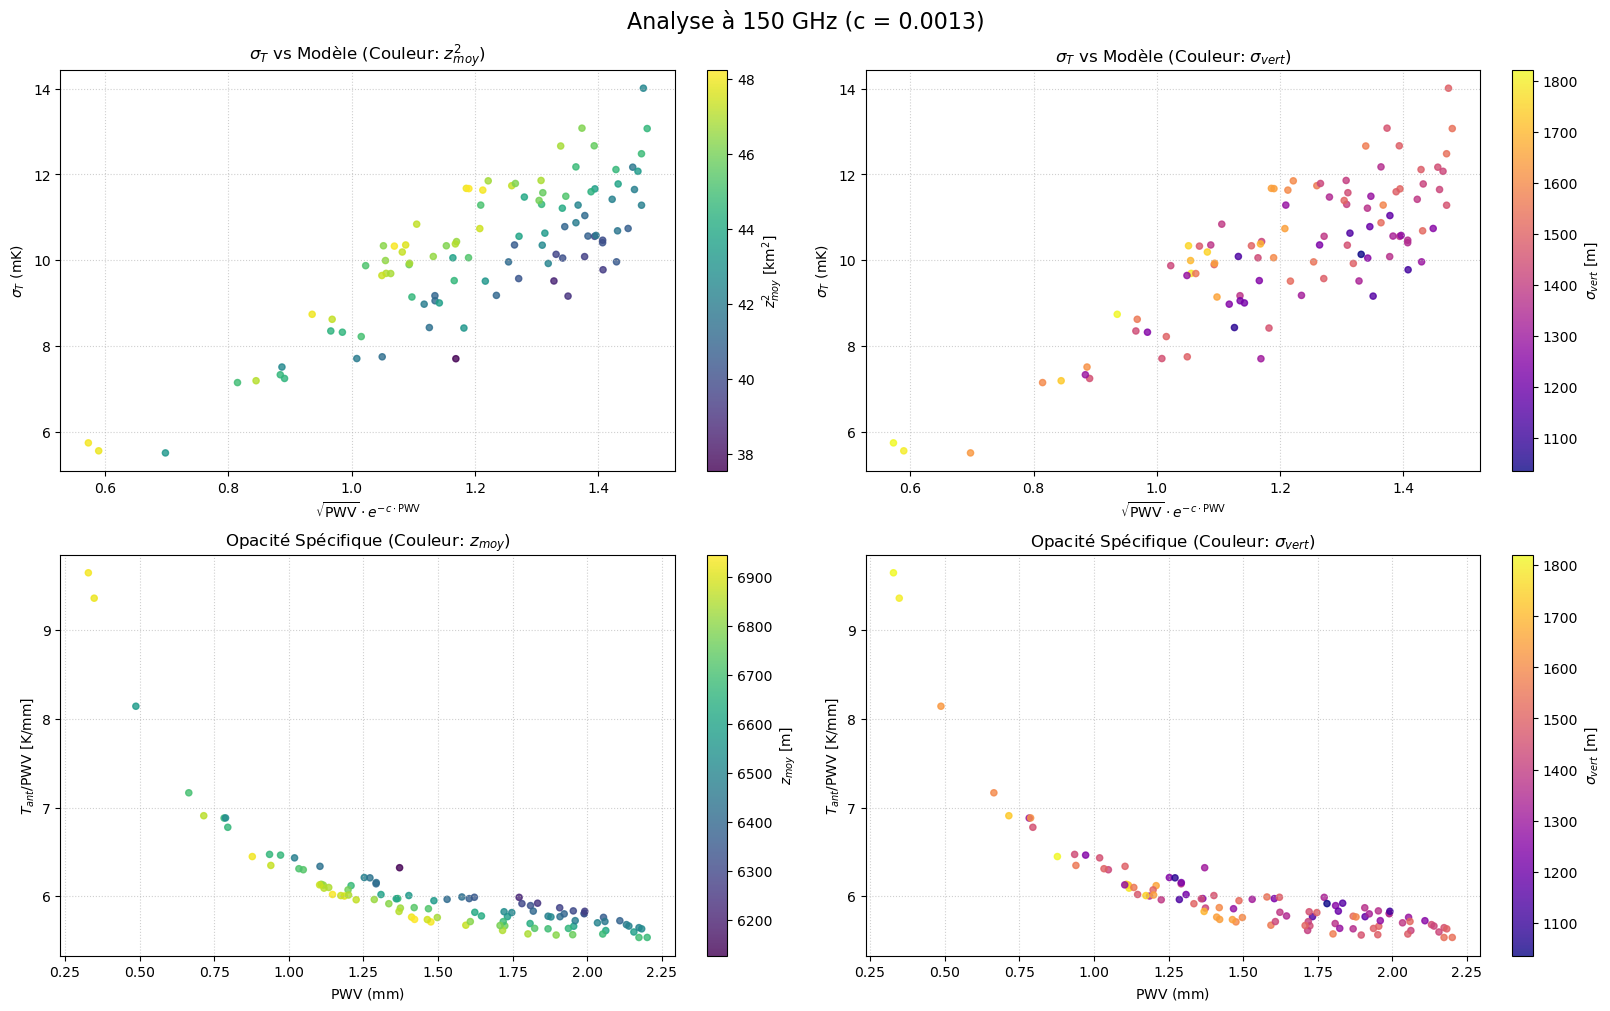

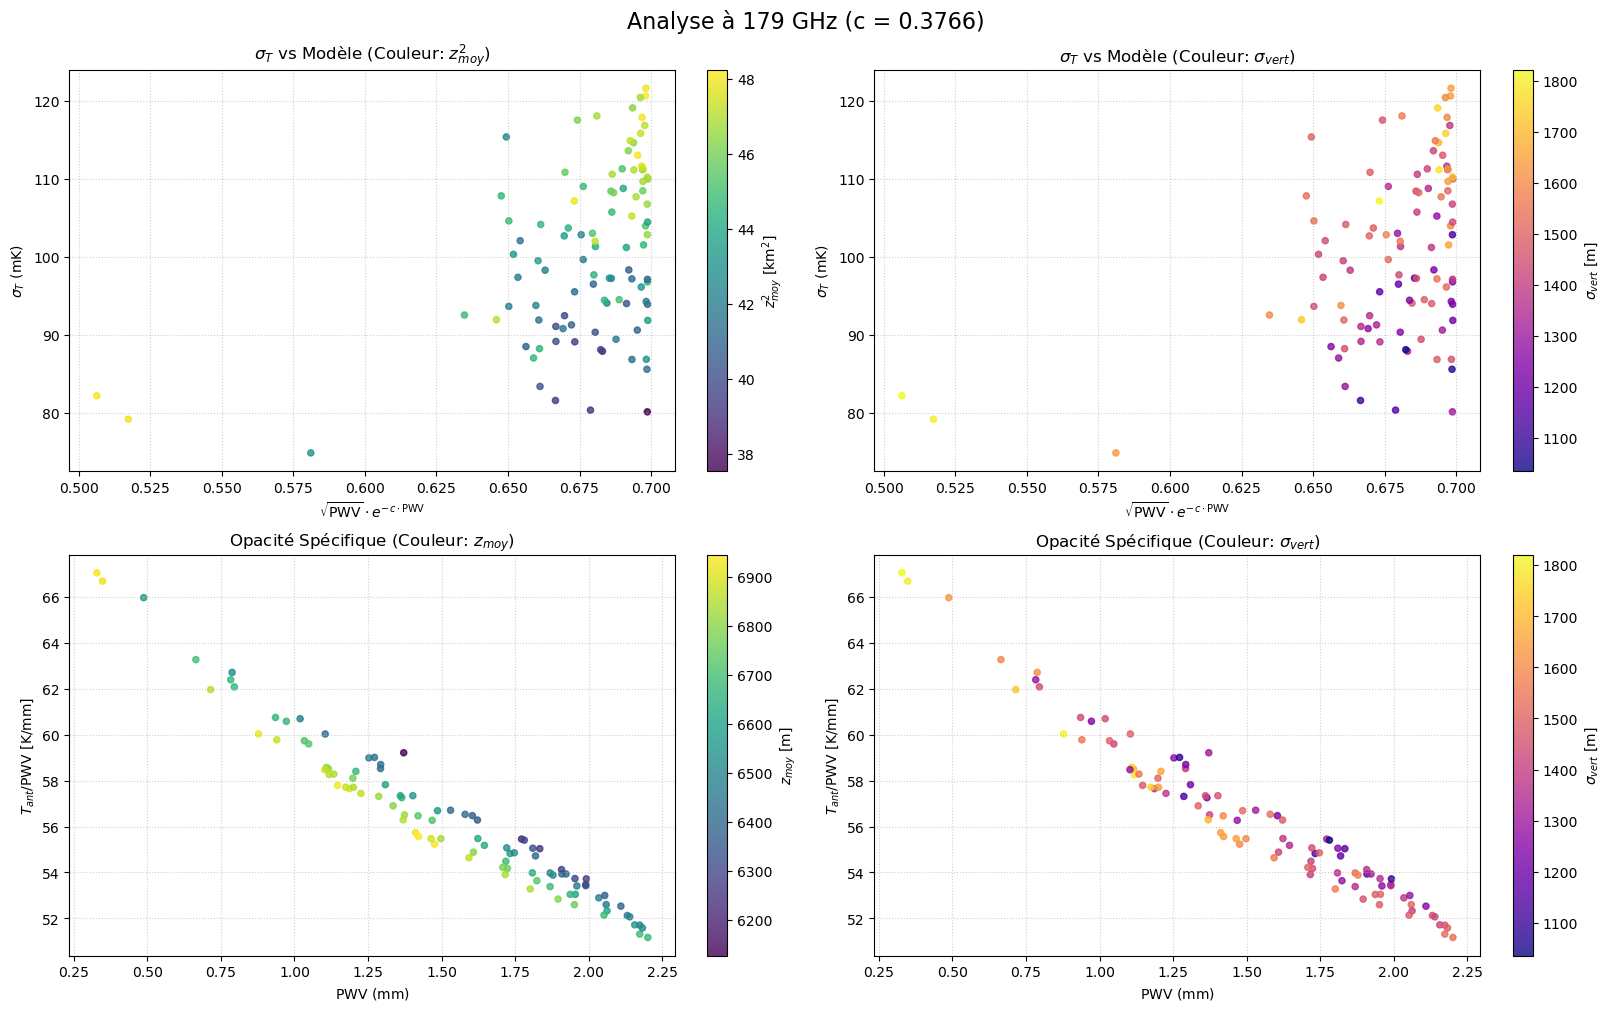

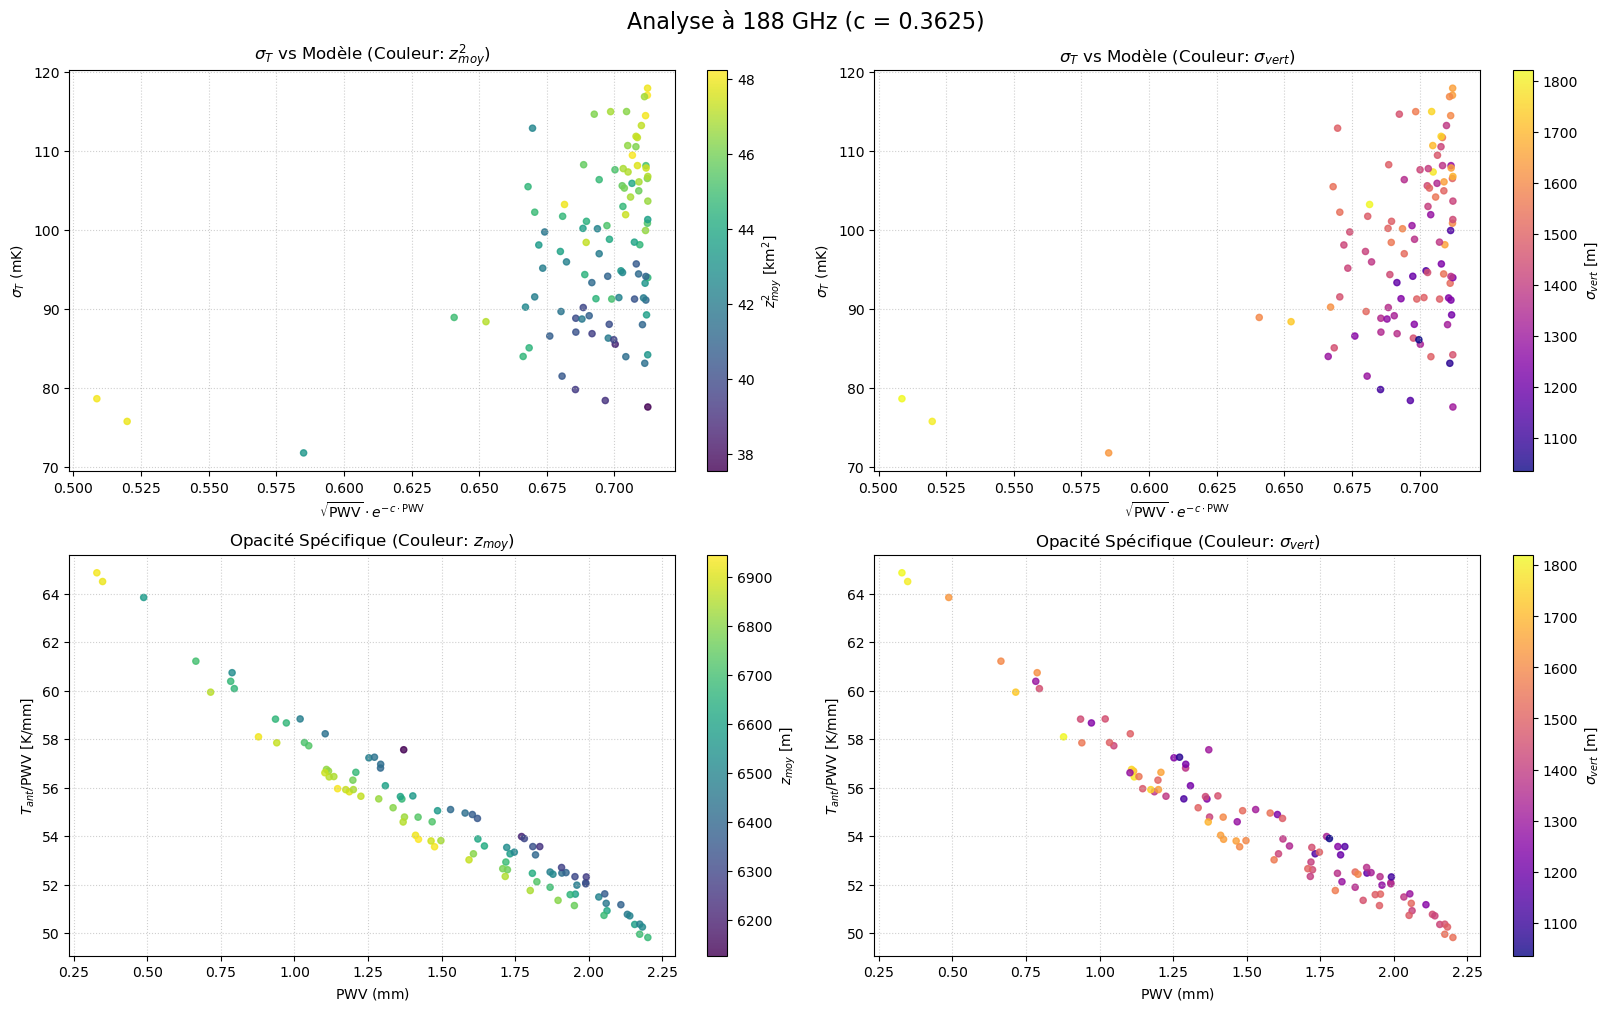

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Paramètres et Coefficients c ---
# Dictionnaire { Fréquence_Hz : coefficient_c }
# (Valeurs issues de vos identifications précédentes)
c_coeffs = {
    120e9: 0,   
    150e9: 0.0013,
    179e9: 0.3766,
    188e9: 0.3625
}

# --- 2. Boucle de Tracé par Fréquence ---

for j, freq in enumerate(frequencies):
    freq_ghz = freq / 1e9
    
    # Récupération des données spécifiques à la fréquence
    sigma_data = sigma_T_res[:, j] * 1000 # Conversion en mK
    tant_data = T_ant_res[:, j]
    
    # Récupération du c associé
    if freq in c_coeffs:
        c = c_coeffs[freq]
    else:
        c = 0 # Valeur par défaut si non trouvée
        print(f"Attention: pas de c trouvé pour {freq_ghz} GHz")

    # Calcul des vecteurs X et Y transformés
    # Modèle linéaire : sqrt(PWV) * exp(-c*PWV)
    x_model = np.sqrt(PWV_res) * np.exp(-c * PWV_res)
    
    # Opacité spécifique : T_ant / PWV
    # Sécurité pour éviter la division par zéro
    safe_pwv = np.where(PWV_res == 0, np.nan, PWV_res)
    y_opacity = tant_data / safe_pwv
    
    # --- Création de la Figure (2 lignes, 2 colonnes) ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    fig.suptitle(f"Analyse à {freq_ghz:.0f} GHz (c = {c})", fontsize=16)

    # =========================================================================
    # PLOT 1 : Sigma vs Modèle (Couleur : z_moy^2)
    # =========================================================================
    ax = axes[0, 0]
    # On divise z_moy^2 par 1e6 pour avoir des unités lisibles (km^2)
    color_data = (z_moy_res**2) / 1e6 
    
    sc1 = ax.scatter(x_model, sigma_data, c=color_data, cmap='viridis', s=20, alpha=0.8)
    
    ax.set_xlabel(r"$\sqrt{\mathrm{PWV}} \cdot e^{-c \cdot \mathrm{PWV}}$")
    ax.set_ylabel(r"$\sigma_{T} \ (\mathrm{mK})$")
    ax.set_title(r"$\sigma_T$ vs Modèle (Couleur: $z_{moy}^2$)")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    cb1 = fig.colorbar(sc1, ax=ax)
    cb1.set_label(r"$z_{moy}^2 \ [\mathrm{km}^2]$")

    # =========================================================================
    # PLOT 2 : Sigma vs Modèle (Couleur : std_vert)
    # =========================================================================
    ax = axes[0, 1]
    color_data = std_vert_res
    
    sc2 = ax.scatter(x_model, sigma_data, c=color_data, cmap='plasma', s=20, alpha=0.8)
    
    ax.set_xlabel(r"$\sqrt{\mathrm{PWV}} \cdot e^{-c \cdot \mathrm{PWV}}$")
    ax.set_ylabel(r"$\sigma_{T} \ (\mathrm{mK})$")
    ax.set_title(r"$\sigma_T$ vs Modèle (Couleur: $\sigma_{vert}$)")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    cb2 = fig.colorbar(sc2, ax=ax)
    cb2.set_label(r"$\sigma_{vert} \ [\mathrm{m}]$")

    # =========================================================================
    # PLOT 3 : T_ant/PWV vs PWV (Couleur : z_moy)
    # =========================================================================
    ax = axes[1, 0]
    color_data = z_moy_res
    
    sc3 = ax.scatter(PWV_res, y_opacity, c=color_data, cmap='viridis', s=20, alpha=0.8)
    
    ax.set_xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
    ax.set_ylabel(r"$T_{ant} / \mathrm{PWV} \ [\mathrm{K/mm}]$")
    ax.set_title(r"Opacité Spécifique (Couleur: $z_{moy}$)")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    cb3 = fig.colorbar(sc3, ax=ax)
    cb3.set_label(r"$z_{moy} \ [\mathrm{m}]$")

    # =========================================================================
    # PLOT 4 : T_ant/PWV vs PWV (Couleur : std_vert)
    # =========================================================================
    ax = axes[1, 1]
    color_data = std_vert_res
    
    sc4 = ax.scatter(PWV_res, y_opacity, c=color_data, cmap='plasma', s=20, alpha=0.8)
    
    ax.set_xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
    ax.set_ylabel(r"$T_{ant} / \mathrm{PWV} \ [\mathrm{K/mm}]$")
    ax.set_title(r"Opacité Spécifique (Couleur: $\sigma_{vert}$)")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    cb4 = fig.colorbar(sc4, ax=ax)
    cb4.set_label(r"$\sigma_{vert} \ [\mathrm{m}]$")

    # Sauvegarde (Optionnel)
    # plt.savefig(f"analyse_multidim_{freq_ghz:.0f}GHz.pdf", bbox_inches='tight')
    
    plt.show()

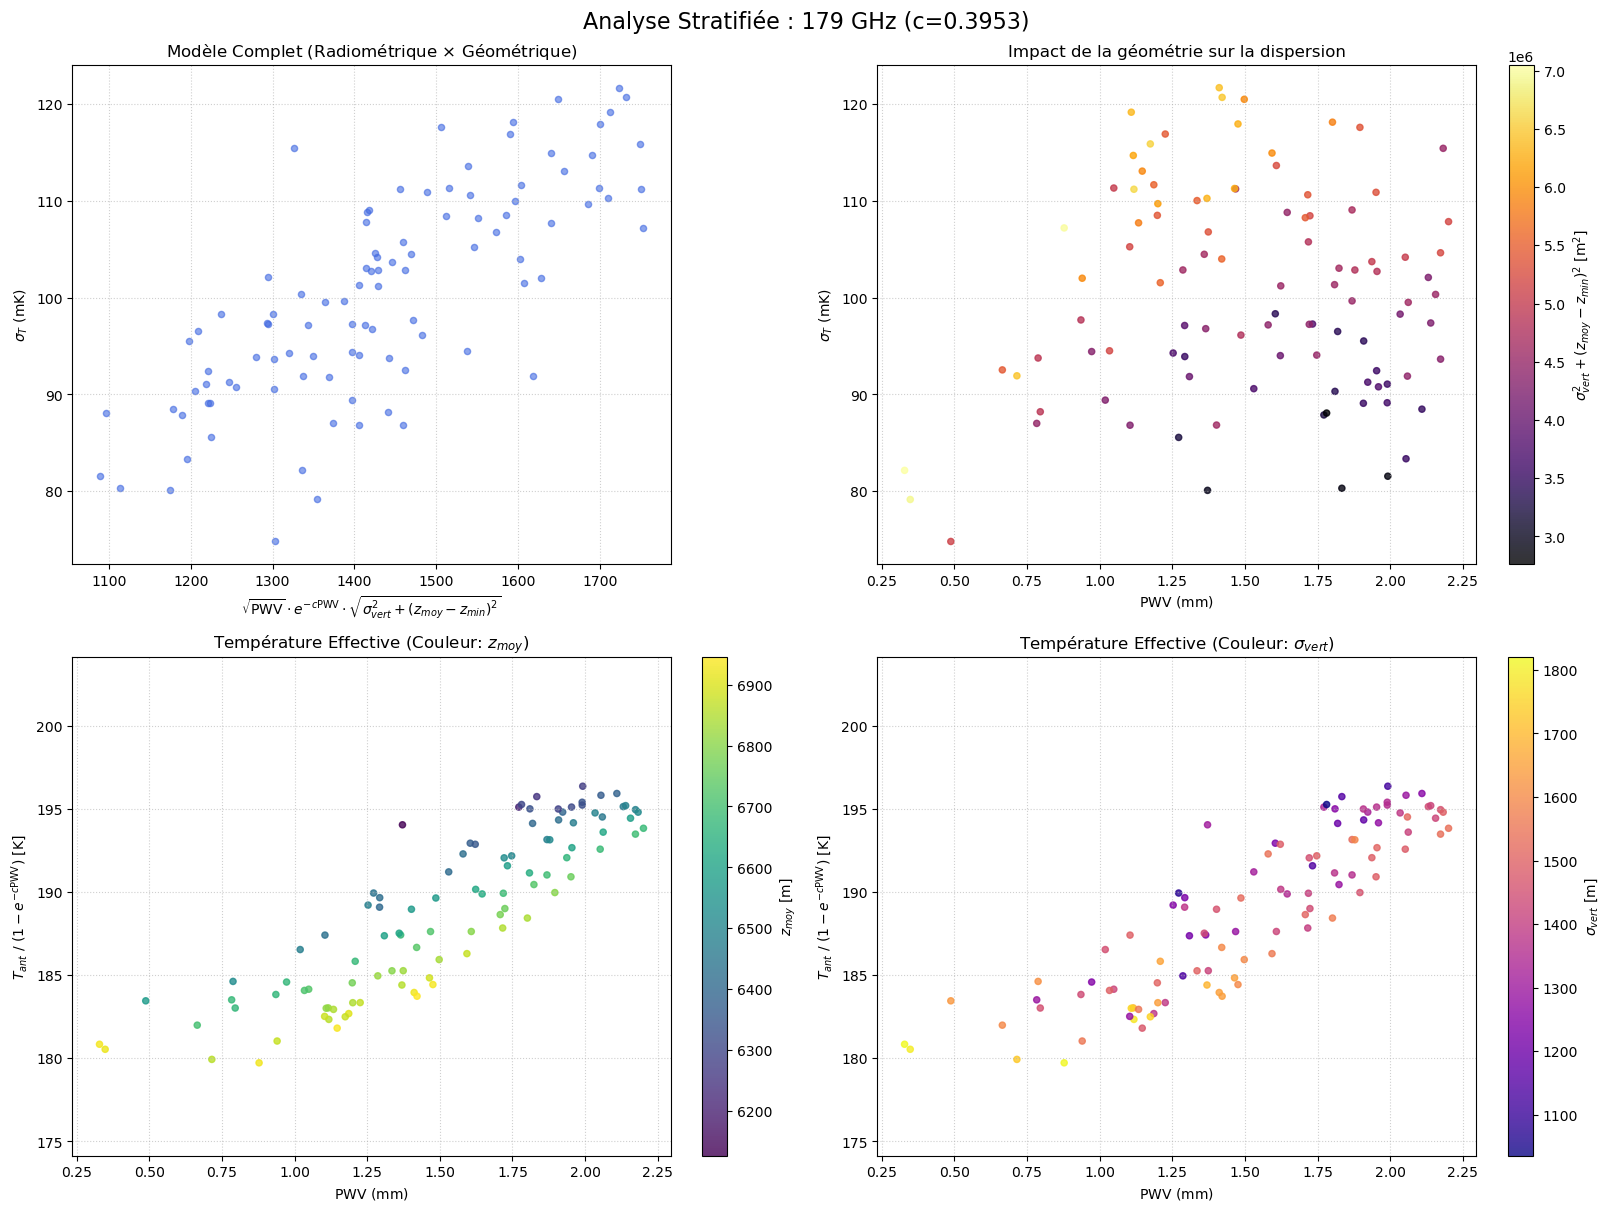

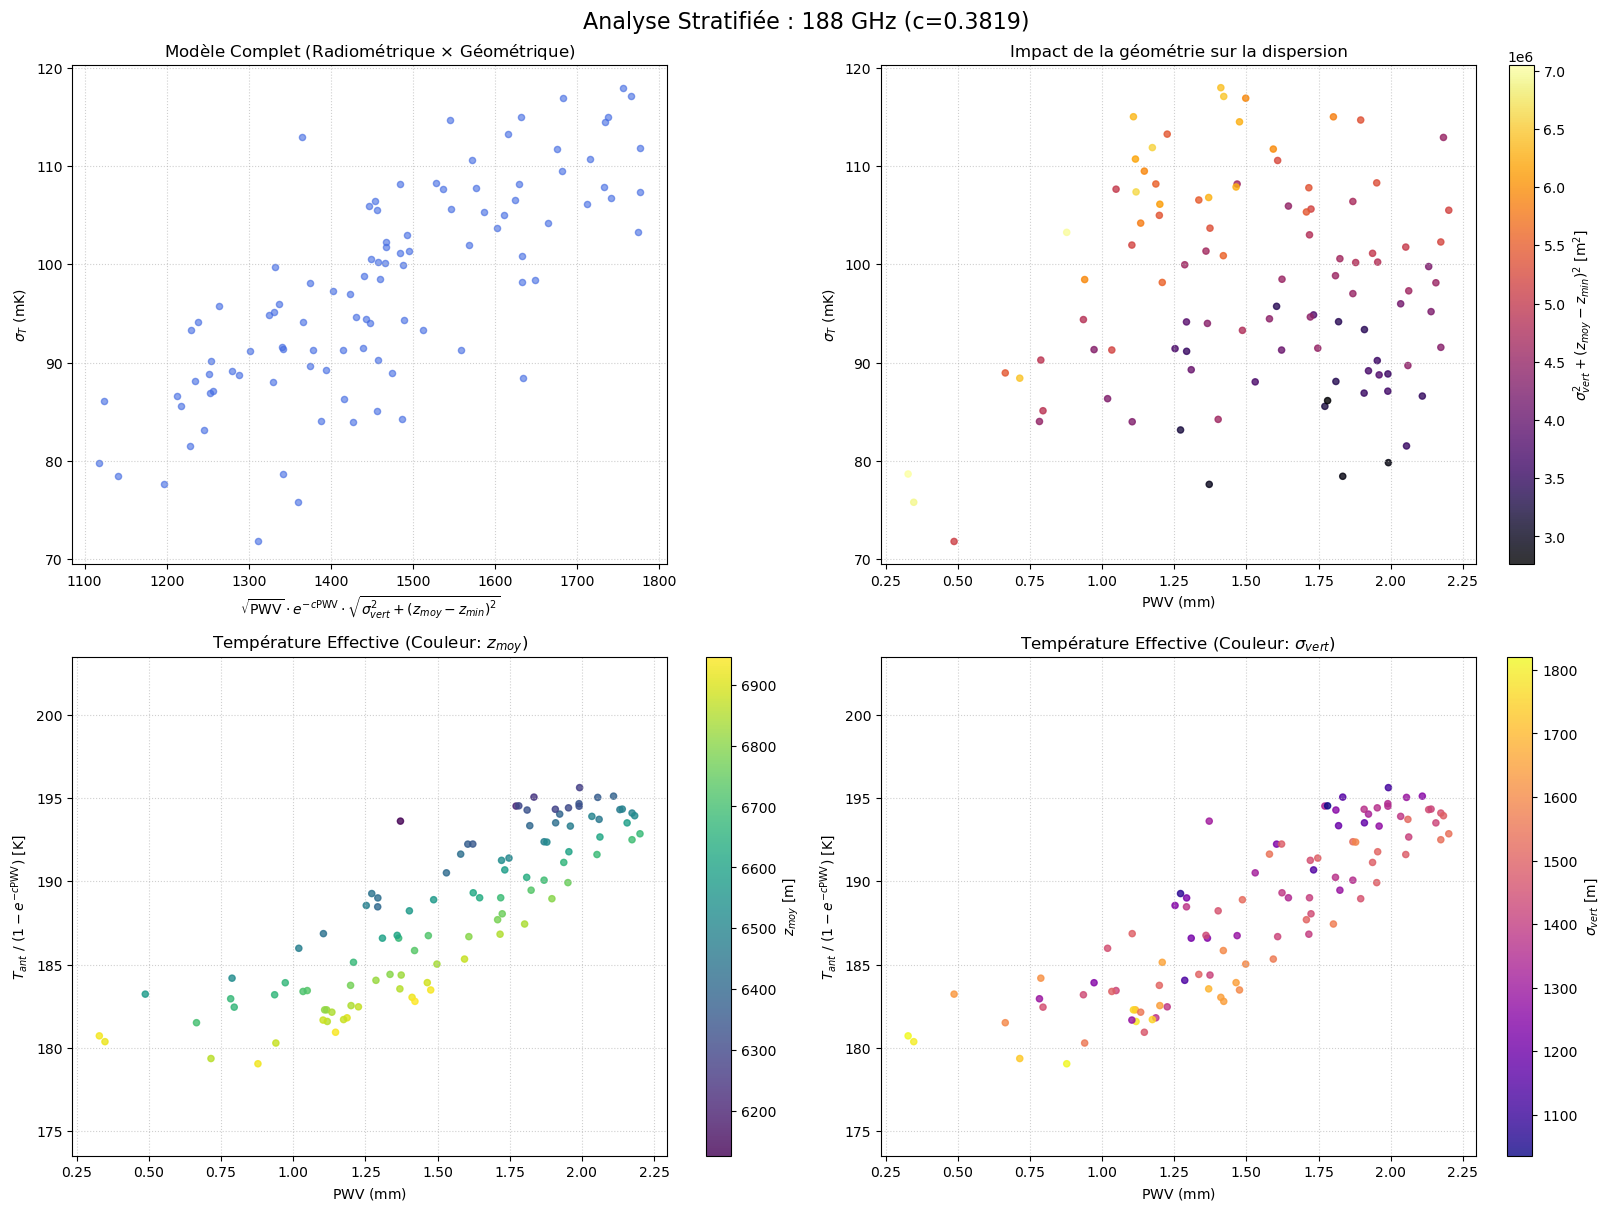

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Paramètres ---
# On ne garde que les fréquences demandées
target_frequencies = [179e9, 188e9]
Z_min = 5000  # Altitude de base (observateur)

# Rappel des c
c_coeffs = {
    179e9: 0.3953,
    188e9: 0.3819
}

# --- 2. Boucle sur les fréquences cibles ---
for j, freq in enumerate(frequencies):
    # On ne traite que si la fréquence est dans la liste cible
    if freq not in target_frequencies:
        continue
        
    freq_ghz = freq / 1e9
    c = c_coeffs.get(freq, 0)
    
    # Données Y
    sigma_data = sigma_T_res[:, j] * 1000 # mK
    tant_data = T_ant_res[:, j]           # K
    
    # Termes géométriques
    # Terme demandé : sqrt( std^2 + (z_moy - z_min)^2 )
    geom_factor = np.sqrt(std_vert_res**2 + (z_moy_res - Z_min)**2)
    # Pour la colorbar du graphe 2 (c'est le carré du terme ci-dessus)
    geom_factor_sq = std_vert_res**2 + (z_moy_res - Z_min)**2
    
    # Variables X complexes
    # X1 = sqrt(PWV) * exp(-c*PWV) * geom_factor
    x_model_geom = np.sqrt(PWV_res) * np.exp(-c * PWV_res) * geom_factor
    
    # Variable Y transformée (T_effective)
    # Y3 = T_ant / (1 - exp(-c*PWV))
    # Sécurité pour PWV=0
    denom = 1 - np.exp(-c * PWV_res)
    denom[denom < 1e-6] = np.nan # Évite division par zero
    y_teff = tant_data / denom

    # --- CRÉATION DE LA FIGURE ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    fig.suptitle(f"Analyse Stratifiée : {freq_ghz:.0f} GHz (c={c})", fontsize=16)

    # -------------------------------------------------------------------------
    # GRAPHE 1 : Sigma vs Modèle Complet (Sans Colorbar)
    # -------------------------------------------------------------------------
    ax = axes[0, 0]
    ax.scatter(x_model_geom, sigma_data, s=20, alpha=0.6, color='royalblue')
    
    ax.set_xlabel(r"$\sqrt{\mathrm{PWV}} \cdot e^{-c\mathrm{PWV}} \cdot \sqrt{\sigma_{vert}^2 + (z_{moy}-z_{min})^2}$")
    ax.set_ylabel(r"$\sigma_{T} \ (\mathrm{mK})$")
    ax.set_title(r"Modèle Complet (Radiométrique $\times$ Géométrique)")
    ax.grid(True, linestyle=':', alpha=0.6)

    # -------------------------------------------------------------------------
    # GRAPHE 2 : Sigma vs PWV (Colorbar : Terme Géométrique au carré)
    # -------------------------------------------------------------------------
    ax = axes[0, 1]
    sc2 = ax.scatter(PWV_res, sigma_data, c=geom_factor_sq, cmap='inferno', s=20, alpha=0.8)
    
    ax.set_xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
    ax.set_ylabel(r"$\sigma_{T} \ (\mathrm{mK})$")
    ax.set_title(r"Impact de la géométrie sur la dispersion")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    cb2 = fig.colorbar(sc2, ax=ax)
    cb2.set_label(r"$\sigma_{vert}^2 + (z_{moy}-z_{min})^2 \ [\mathrm{m}^2]$")

    # -------------------------------------------------------------------------
    # GRAPHE 3 : T_ant Normalisée vs PWV (Colorbar : z_moy)
    # -------------------------------------------------------------------------
    ax = axes[1, 0]
    sc3 = ax.scatter(PWV_res, y_teff, c=z_moy_res, cmap='viridis', s=20, alpha=0.8)
    
    ax.set_xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
    ax.set_ylabel(r"$T_{ant} \ / \ (1 - e^{-c\mathrm{PWV}}) \ [\mathrm{K}]$")
    ax.set_title(r"Température Effective (Couleur: $z_{moy}$)")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # On ajuste l'échelle Y pour voir les variations fines (souvent T_eff est assez constante)
    # On centre autour de la médiane avec +/- 10K par exemple
    med_y = np.nanmedian(y_teff)
    ax.set_ylim(med_y - 15, med_y + 15)
    
    cb3 = fig.colorbar(sc3, ax=ax)
    cb3.set_label(r"$z_{moy} \ [\mathrm{m}]$")

    # -------------------------------------------------------------------------
    # GRAPHE 4 : T_ant Normalisée vs PWV (Colorbar : std_vert)
    # -------------------------------------------------------------------------
    ax = axes[1, 1]
    sc4 = ax.scatter(PWV_res, y_teff, c=std_vert_res, cmap='plasma', s=20, alpha=0.8)
    
    ax.set_xlabel(r"$\mathrm{PWV} \ (\mathrm{mm})$")
    ax.set_ylabel(r"$T_{ant} \ / \ (1 - e^{-c\mathrm{PWV}}) \ [\mathrm{K}]$")
    ax.set_title(r"Température Effective (Couleur: $\sigma_{vert}$)")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(med_y - 15, med_y + 15)
    
    cb4 = fig.colorbar(sc4, ax=ax)
    cb4.set_label(r"$\sigma_{vert} \ [\mathrm{m}]$")

    plt.show()